# SPLINTER V012
### "The Linear Spline Interannual Trend Evaluator"

A linear spline + Fourier function generalized additive model (GAM) with outlier detection and removal for time series analysis of environmental monitoring data for chemical contaminants.

This notebook analyzes time series data using GAM decomposition, change point detection, and outlier removal. All outputs (plots, tables) can be saved automatically to a timestamped directory.

Code developed and maintained by Matthew MacLeod, Stockholm University with contributions from XXX as a resource for the Arctic Monitoring and Assessment Programme (AMAP).

### Notebook Execution Order

**Important:** The cells must be run in order for the workflow to succeed.  If you use "Run All", the notebook works as intended.

In [ ]:
#1. --- USER INPUTS ---
import os
from datetime import datetime
notebook_name = 'SPLINTER_V012'  # Used in output directory naming; update if you rename the notebook

# relative path to the datafiles directory from the current working directory
# NOTE: put this notebook and the input data under the same root folder
current_dir = os.getcwd()
input_path = os.path.join(current_dir, "PAH_PCB")

# ─── RUN MODE SELECTION ────────────────────────────────────────────────────
# Set run_mode to:
#   1 = Run SPLINTER on ALL NetCDF files in the input_path/datafiles directory
#   2 = Run SPLINTER for a specific combination of station_code,
#           instrument_type, component, and matrix
run_mode = 1

# ─── MATRIX ALIASES ────────────────────────────────────────────────────────
# Matrices listed here are treated as equivalent.
# The dict value is the canonical name used in batch combinations and output filenames;
# the dict key is the alternative name as it may appear in EBAS filenames.
MATRIX_ALIASES = {
    "air+pm10": "air+aerosol",
}

# ─── OPTION 1: All data — discover and queue all unique combinations ─────────
if run_mode == 1:
    import glob as _glob

    _datafiles_dir = input_path #os.path.join(input_path.rstrip('/'), "datafiles")
    _all_nc = sorted(
        f for f in _glob.glob(os.path.join(_datafiles_dir, "*.nc"))
        if '_dup' not in os.path.basename(f)   # exclude lab-duplicate files
    )

    # EBAS filename structure:
    # {station_code}.{start_date}.{end_date}.{instrument_type}.{component}.{matrix}.*.nc
    _seen = set()
    batch_combinations = []
    for _fpath in _all_nc:
        _parts = os.path.basename(_fpath).split(".")
        if len(_parts) >= 7:
            _comp = _parts[4]                # component
            _mx_raw = _parts[5]              # matrix as in filename
            _mx_norm = MATRIX_ALIASES.get(_mx_raw, _mx_raw)
            # skip if component or matrix is empty after normalization (e.g. due to missing value in filename)
            if not _comp or not _mx_norm:
                continue
            _combo = (_parts[0], _parts[3], _comp, _mx_norm)
            if _combo not in _seen:
                _seen.add(_combo)
                batch_combinations.append(_combo)
    batch_combinations.sort()

    batch_index = 0  # Tracks progress; advanced by the final Batch Advance cell

    # Placeholders — overwritten per-combination when Cell 6 runs
    station_code = instrument_type = component = matrix = input_subst = None

    _unique_stations    = len(set(c[0] for c in batch_combinations))
    _unique_instruments = len(set(c[1] for c in batch_combinations))
    _unique_components  = len(set(c[2] for c in batch_combinations))
    _unique_matrices    = len(set(c[3] for c in batch_combinations))

    print(f"Scanning   : {_datafiles_dir}")
    print(f"NC files   : {len(_all_nc)}")
    print(f"Unique combinations to process: {len(batch_combinations)}")
    print(f"  Unique station_codes   : {_unique_stations}")
    print(f"  Unique instrument_types: {_unique_instruments}")
    print(f"  Unique components      : {_unique_components}")
    print(f"  Unique matrices        : {_unique_matrices}\n")
    _cw = [5, 12, 22, 38, 14]
    print(f"{'#':<{_cw[0]}}{'Station':<{_cw[1]}}{'Instrument':<{_cw[2]}}{'Component':<{_cw[3]}}{'Matrix'}")
    print("─" * sum(_cw))
    for _i, (_sc, _it, _comp, _mx) in enumerate(batch_combinations, 1):
        print(f"{_i:<{_cw[0]}}{_sc:<{_cw[1]}}{_it:<{_cw[2]}}{_comp:<{_cw[3]}}{_mx}")

# ─── OPTION 2: Specific station / instrument / component / matrix ───────────
elif run_mode == 2:
    station_code    = "CA0001R"           # e.g. "CA0001R", "SE0014R", "RU0100R"
    instrument_type = "high_vol_sampler"  # e.g. "high_vol_sampler", "passive_puf", "low_vol_sampler"
    component       = "HCB"  # e.g. "benzo_a_pyrene", "HCB", "PCB_153"
    matrix          = "air+aerosol"       # e.g. "air+aerosol", "air", "aerosol"

    # Alias so downstream cells that reference input_subst remain compatible
    input_subst = component

else:
    raise ValueError(f"Invalid run_mode: {run_mode}. Choose 1 or 2.")

# Toggle to enable saving outputs
save_outputs = True  # Set to False to disable saving

# Linear Spline Fitting Constraints
# These settings help control overfitting by limiting knot placement
# If you make MaxKnotPeriod and/or MinKnotInterval smaller more knots will be allowed and calculation time will increase!!
MaxKnotPeriod = 3  # Default = 3 Years... Max number of knots = timespan / MaxKnotPeriod
MinKnotInterval = 3  # Default = 3 Years...  Minimum spacing between knots
StartPad = 2  # Default = 2 Years to not allow a knot at start of time series for spline fitting

# ─── End-of-series knot restriction — choose ONE of the two options below ─────
# Option A — EndPad: forbid knots within this many years of the data end.
#            Used whenever LastKnotYear (Option B) is None.
EndPad = 2    # Default = 2Years before end of data where knots are forbidden

# Option B — LastKnotYear: specify the last decimal year at which a knot may
#            be placed.  EndPad is then computed automatically for each dataset
#            as  EndPad = t[-1] − LastKnotYear.  Overrides EndPad when not None.
#            Set to None to use the fixed EndPad value above instead.
LastKnotYear = None  # e.g. 2015.0  →  no knots allowed after that year
_user_EndPad = EndPad  # Preserve user-set value; used as fallback if data ends before LastKnotYear
# ──────────────────────────────────────────────────────────────────────────────

# USER OPTIONS FOR MDL HANDLING
# ==============================
# Flag 780: Below MDL but value reported
handle_flag_780 = "Keep"  # Options: "Keep" or "Remove"

# Flag 781: Below MDL and MDL is reported
handle_flag_781 = "Replace"  # Options: "Keep", "Remove", or "Replace" with 0.5*MDL

# Generate output directory name

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

project_root = os.path.dirname(os.path.dirname(input_path))

if run_mode == 2:
    output_dir = os.path.join(
        project_root,
        "outputdirs",
        f"{station_code}_{instrument_type}_{component}_{matrix}_output_{notebook_name}_{timestamp}"
    )
elif run_mode == 1:
    output_dir = None  # Set per-combination in Cell 6 (batch mode)

if run_mode == 2:
    if save_outputs:
        os.makedirs(output_dir, exist_ok=True)
        print(f"Outputs will be saved to: {output_dir}")
    else:
        print("Output saving is disabled.")
elif run_mode == 1:
    print("Batch mode active: output directories will be created per-combination.")


Scanning   : c:\XiaoyuGithub\SPLINTER\SPLINTER\PAH_PCB
NC files   : 63
Unique combinations to process: 32
  Unique station_codes   : 1
  Unique instrument_types: 2
  Unique components      : 20
  Unique matrices        : 3

#    Station     Instrument            Component                             Matrix
───────────────────────────────────────────────────────────────────────────────────────────
1    NO0042G     high_vol_sampler      HCB                                   air+aerosol
2    NO0042G     high_vol_sampler      PCB_153                               air+aerosol
3    NO0042G     high_vol_sampler      PCB_28                                air+aerosol
4    NO0042G     high_vol_sampler      acenaphthene                          air+aerosol
5    NO0042G     high_vol_sampler      acenaphthylene                        air+aerosol
6    NO0042G     high_vol_sampler      anthracene                            air+aerosol
7    NO0042G     high_vol_sampler      benz_a_anthracene          

In [ ]:
#2.  --- IMPORTS ---
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import ruptures as rpt  # change point detection
from statsmodels.graphics.tsaplots import plot_acf
import warnings
from itertools import product, combinations
from scipy import stats as sp_stats
from datetime import datetime
import glob
import xarray as xr
import os
from scipy import stats as sp_stats

In [3]:
#3 --- HELPER FUNCTIONS FOR SAVING OUTPUTS ---
output_counter = {'value': 1}  # Mutable counter for output numbering
def get_next_output_number():
    val = output_counter['value']
    output_counter['value'] += 1
    return val

def save_plot(fig, name):
    if save_outputs:
        num = get_next_output_number()
        fig.savefig(os.path.join(output_dir, f"{num:02d}_{name}.png"), bbox_inches='tight')
        plt.close(fig)

def save_df(df, name):
    if save_outputs:
        num = get_next_output_number()
        df.to_csv(os.path.join(output_dir, f"{num:02d}_{name}.csv"), index=False)

def save_text(text, name):
    if save_outputs:
        num = get_next_output_number()
        with open(os.path.join(output_dir, f"{num:02d}_{name}.txt"), 'w', encoding='utf-8-sig') as f:
            ascii_text = text.replace('–', '-').replace('—', '--').replace('−', '-')
            f.write(ascii_text)


In [4]:
# project root (SPLINTER folder)
project_root = input_path.rstrip('/')

# datafiles directory
datafiles_dir = os.path.join(project_root) #, "datafiles")

# All filename variants that map to the current canonical matrix value
def _matrix_variants(canonical):
    """Return all filename matrix strings that correspond to a canonical matrix."""
    aliases = [m for m, c in MATRIX_ALIASES.items() if c == canonical]
    return sorted({canonical} | set(aliases))

# ─── MODE 2: Single specific combination ─────────────────────────────────────
if run_mode == 2:
    # EBAS filename: {station_code}.{start}.{end}.{instrument_type}.{component}.{matrix}.*.nc
    sc  = glob.escape(station_code)
    it  = glob.escape(instrument_type)
    cmp = glob.escape(component)
    nc_files = sorted({
        f
        for _mxv in _matrix_variants(matrix)
        for f in glob.glob(os.path.join(datafiles_dir, f"{sc}.*.*.{it}.{cmp}.{glob.escape(_mxv)}.*.nc"))
        if '_dup' not in os.path.basename(f)   # exclude lab-duplicate files
    })

    if not nc_files:
        raise FileNotFoundError(
            f"No NetCDF files found in {datafiles_dir} matching:\n"
            f"  station_code    = {station_code!r}\n"
            f"  instrument_type = {instrument_type!r}\n"
            f"  component       = {component!r}\n"
            f"  matrix          = {matrix!r}"
        )

    print(f"Found {len(nc_files)} NetCDF file(s):")
    for fn in nc_files:
        print("  ", fn)

    _label    = f"{station_code} | {component} | {matrix}"
    _label_fn = f"{station_code}_{component}_{matrix}"
    _file_list_text = "\n".join([
        f"NetCDF files globbed for {input_subst} | {_label}",
        f"Source directory: {datafiles_dir}",
        f"Total files found: {len(nc_files)}", "",
    ] + [os.path.basename(fn) for fn in nc_files])
    _lky_str = str(LastKnotYear) if LastKnotYear is not None else "None (EndPad used)"
    _settings_tbl1 = (
        "\nRun Settings\n"
        "============\n"
        "Station / Instrument / Component / Matrix\n"
        f"  {'Station code':<20}: {station_code}\n"
        f"  {'Instrument type':<20}: {instrument_type}\n"
        f"  {'Component':<20}: {component}\n"
        f"  {'Matrix':<20}: {matrix}\n"
    )
    _settings_tbl2 = (
        "\nModel Knot / Pad Parameters\n"
        "===========================\n"
        f"  {'MaxKnotPeriod':<20}: {MaxKnotPeriod} yr\n"
        f"  {'MinKnotInterval':<20}: {MinKnotInterval} yr\n"
        f"  {'StartPad':<20}: {StartPad} yr\n"
        f"  {'EndPad':<20}: {EndPad:.2f} yr\n"
        f"  {'LastKnotYear':<20}: {_lky_str}\n"
    )
    save_text(_file_list_text + _settings_tbl1 + _settings_tbl2, f'SPLINTER_Settings_{_label_fn}')

# ─── MODE 1: Batch — set up variables for the current combination ─────────────
elif run_mode == 1:
    if not batch_combinations:
        raise RuntimeError("batch_combinations is empty — re-run Cell 3.")

    if batch_index >= len(batch_combinations):
        print(f"✓  All {len(batch_combinations)} combinations already processed.")
        print("   Set batch_index = 0 in Cell 3 and re-run from here to restart.")
        nc_files = []
    else:
        station_code, instrument_type, component, matrix = batch_combinations[batch_index]
        input_subst = component

        # Per-combination output directory (timestamp is fixed for the whole batch run).
        # Use one dirname on the stripped path → lands at TemporalTrends/outputdirs/…
        # (same parent as mode 2), NOT two dirnames which would go up to AMAP/outputdirs/…
        output_dir = os.path.join(
            os.path.dirname(input_path.rstrip('/')),
            "outputdirs",
            f"{station_code}_{component}_{instrument_type}_{matrix}_output_{notebook_name}_{timestamp}"
        )
        if save_outputs:
            os.makedirs(output_dir, exist_ok=True)
        output_counter['value'] = 1  # Reset file-numbering for each combination

        print(f"\n{'='*72}")
        print(f"  Batch {batch_index + 1} / {len(batch_combinations)}")
        print(f"  Station Code    : {station_code}")
        print(f"  Instrument Type : {instrument_type}")
        print(f"  Component       : {component}")
        print(f"  Matrix          : {matrix}")
        if save_outputs:
            print(f"  Output dir      : {output_dir}")
        print(f"{'='*72}")

        sc  = glob.escape(station_code)
        it  = glob.escape(instrument_type)
        cmp = glob.escape(component)
        nc_files = sorted({
            f
            for _mxv in _matrix_variants(matrix)
            for f in glob.glob(os.path.join(datafiles_dir, f"{sc}.*.*.{it}.{cmp}.{glob.escape(_mxv)}.*.nc"))
            if '_dup' not in os.path.basename(f)   # exclude lab-duplicate files
        })

        if not nc_files:
            print("  ⚠  No NetCDF files found for this combination.")
        else:
            print(f"  Files : {len(nc_files)}")
            for fn in nc_files:
                print(f"    {os.path.basename(fn)}")

        if save_outputs and nc_files:
            _label    = f"{station_code} | {component} | {instrument_type} | {matrix}"
            _label_fn = f"{station_code}_{component}_{instrument_type}_{matrix}"
            _file_list_text = "\n".join([
                f"NetCDF files globbed for {input_subst} | {_label}",
                f"Source directory: {datafiles_dir}",
                f"Total files found: {len(nc_files)}", "",
            ] + [os.path.basename(fn) for fn in nc_files])
            _lky_str = str(LastKnotYear) if LastKnotYear is not None else "None (EndPad used)"
            _settings_tbl1 = (
                "\nRun Settings\n"
                "============\n"
                "Station / Instrument / Component / Matrix\n"
                f"  {'Station code':<20}: {station_code}\n"
                f"  {'Instrument type':<20}: {instrument_type}\n"
                f"  {'Component':<20}: {component}\n"
                f"  {'Matrix':<20}: {matrix}\n"
            )
            _settings_tbl2 = (
                "\nModel Knot / Pad Parameters\n"
                "===========================\n"
                f"  {'MaxKnotPeriod':<20}: {MaxKnotPeriod} yr\n"
                f"  {'MinKnotInterval':<20}: {MinKnotInterval} yr\n"
                f"  {'StartPad':<20}: {StartPad} yr\n"
                f"  {'EndPad':<20}: {EndPad:.2f} yr\n"
                f"  {'LastKnotYear':<20}: {_lky_str}\n"
            )
            save_text(_file_list_text + _settings_tbl1 + _settings_tbl2, f'SPLINTER_Settings_{_label_fn}')



  Batch 1 / 32
  Station Code    : NO0042G
  Instrument Type : high_vol_sampler
  Component       : HCB
  Matrix          : air+aerosol
  Output dir      : c:\XiaoyuGithub\SPLINTER\SPLINTER\outputdirs\NO0042G_HCB_high_vol_sampler_air+aerosol_output_SPLINTER_V012_20260602_132435
  Files : 3
    NO0042G.19930402000000.20181210133000.high_vol_sampler.HCB.air+aerosol.22y.1d.NO01L_fppuf_42b.NO01L_NILU_O_2.lev2.nc
    NO0042G.19990104080000.20181210133000.high_vol_sampler.HCB.air+aerosol.12mo.1d.NO01L_fppuf_42b.NO01L_NILU_O_2.lev2.nc
    NO0042G.20150105094000.20250529000000.high_vol_sampler.HCB.air+aerosol.10y.1w.NO01L_fppuf_42b.NO01L_NILU_O_2.lev2.nc


Station platform code : NO0042S
Station GAW ID        : ZEP

📋 MDL Handling Configuration:
  Flag 780 (Below MDL, value reported): Keep
  Flag 781 (Below MDL, MDL reported): Replace
  ✓ Kept 0 Flag 780 values
  ✓ Replaced 1 Flag 781 values with 0.5*MDL (values range: 2.815e-01 to 2.815e-01)


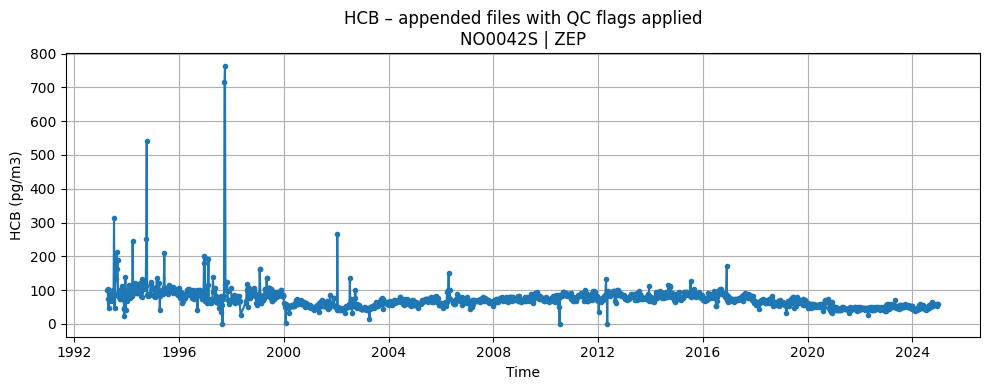


✓ Concatenated data with QC flags:
  Total measurements: 1698

  Flag 780 (Below MDL, value reported): 0 (0.0%)
  Flag 781 (Below MDL, MDL reported): 1 (0.1%)
  Total Below MDL values (780 + 781): 1 (0.1%)
  Valid measurements (above MDL): 1697 (99.9%)


3812

In [5]:

datasets = [xr.open_dataset(f, decode_times=True) for f in nc_files]

# ── Extract station identifiers from first file's global attributes ──────────
station_platform_code = datasets[0].attrs.get('ebas_platform_code', 'UNKNOWN')
station_gaw_id        = datasets[0].attrs.get('ebas_station_gaw_id', 'UNKNOWN')
station_label    = f"{station_platform_code} | {station_gaw_id}"          # for plot titles
station_label_fn = f"{station_platform_code}_{station_gaw_id}"            # for filenames
print(f"Station platform code : {station_platform_code}")
print(f"Station GAW ID        : {station_gaw_id}")
# ─────────────────────────────────────────────────────────────────────────────

# Concatenate both concentration data and QC flags
ts = xr.concat([x[input_subst] for x in datasets], dim="time").sortby("time")

# Concatenate QC flags - extract from all datasets and concatenate
qc_var_name = f"{input_subst}_qc"
qc_flags_list = []
for x in datasets:
    qc_data = x[qc_var_name]  # Shape: (1, time) or similar
    qc_1d = qc_data.isel({dim: 0 for dim in qc_data.dims if dim != 'time'})  # Get just the time dimension
    qc_flags_list.append(qc_1d)

qc_flags = xr.concat(qc_flags_list, dim="time").sortby("time")

# Identify MDL values separately - flag 780 vs 781
flag_780_mask = (qc_flags == 780)  # Below MDL but value reported
flag_781_mask = (qc_flags == 781)  # Below MDL and MDL is reported
mdl_mask = flag_780_mask | flag_781_mask

# Count each flag type
count_780 = flag_780_mask.sum().values
count_781 = flag_781_mask.sum().values
count_mdl_total = mdl_mask.sum().values
total_measurements = len(ts)
count_valid = total_measurements - count_mdl_total

# Calculate percentages
pct_780 = (count_780 / total_measurements * 100) if total_measurements > 0 else 0
pct_781 = (count_781 / total_measurements * 100) if total_measurements > 0 else 0
pct_mdl = (count_mdl_total / total_measurements * 100) if total_measurements > 0 else 0

# Print current configuration
print(f"\n📋 MDL Handling Configuration:")
print(f"  Flag 780 (Below MDL, value reported): {handle_flag_780}")
print(f"  Flag 781 (Below MDL, MDL reported): {handle_flag_781}")

# Apply user-specified handling
ts_values = ts.values.copy()
ts_values_float = ts_values.astype(float)  # Ensure float to handle NaN

# Handle Flag 780
if handle_flag_780 == "Remove":
    ts_values_float[flag_780_mask.values] = np.nan
    print(f"  ✓ Removed {count_780} Flag 780 values")
elif handle_flag_780 == "Keep":
    print(f"  ✓ Kept {count_780} Flag 780 values")

# Handle Flag 781
if handle_flag_781 == "Remove":
    ts_values_float[flag_781_mask.values] = np.nan
    print(f"  ✓ Removed {count_781} Flag 781 values")
elif handle_flag_781 == "Replace":
    # For flag 781, the reported value IS the MDL value
    # Replace each flagged value with 0.5 times that MDL value
    flag_781_indices = flag_781_mask.values
    mdl_values = ts.values[flag_781_indices]  # These are the MDL values for each flag 781 measurement
    if count_781 > 0:
        ts_values_float[flag_781_indices] = 0.5 * mdl_values
        print(f"  ✓ Replaced {count_781} Flag 781 values with 0.5*MDL (values range: {0.5*np.nanmin(mdl_values):.3e} to {0.5*np.nanmax(mdl_values):.3e})")
    else:
        print(f"  ✓ Replace selected for Flag 781 but no Flag 781 values present in this dataset")
elif handle_flag_781 == "Keep":
    print(f"  ✓ Kept {count_781} Flag 781 values")

# Update ts with modified values
ts = ts.copy()
ts.values = ts_values_float

# Create a combined dataset with both concentration and QC flags
combined_data = xr.Dataset({
    'concentration': ts,
    'qc_flags': qc_flags,
    'flag_780': flag_780_mask,  # Below MDL, value reported
    'flag_781': flag_781_mask,  # Below MDL, MDL reported
    'is_mdl': mdl_mask
})

plt.figure(figsize=(10, 4))
plt.plot(ts.time.values, ts.values, ".", linestyle="-")
plt.xlabel("Time")
plt.ylabel(f"{input_subst} ({ts.attrs.get('units', '')})")
plt.title(f"{input_subst} – appended files with QC flags applied\n{station_label}")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.close('all')

print(f"\n✓ Concatenated data with QC flags:")
print(f"  Total measurements: {total_measurements}")
print(f"\n  Flag 780 (Below MDL, value reported): {count_780} ({pct_780:.1f}%)")
print(f"  Flag 781 (Below MDL, MDL reported): {count_781} ({pct_781:.1f}%)")
print(f"  Total Below MDL values (780 + 781): {count_mdl_total} ({pct_mdl:.1f}%)")
print(f"  Valid measurements (above MDL): {count_valid} ({100-pct_mdl:.1f}%)")

# Save MDL Handling Configuration as text file
mdl_config_text = f"""MDL Handling Configuration

Flag 780 (Below MDL, value reported): {handle_flag_780}
Flag 781 (Below MDL, MDL reported): {handle_flag_781}

Statistics:
  Flag 780 count: {count_780} ({pct_780:.1f}%)
  Flag 781 count: {count_781} ({pct_781:.1f}%)
  Total Below MDL values: {count_mdl_total} ({pct_mdl:.1f}%)
  Valid measurements (above MDL): {count_valid} ({100-pct_mdl:.1f}%)
"""
save_text(mdl_config_text, f'MDL_Handling_Configuration_{_label_fn}')

# Close file handles and release dataset objects to prevent memory leaks
for _ds in datasets:
    _ds.close()
del datasets, combined_data
import gc as _gc; _gc.collect()

In [6]:
#4 --- LOAD AND PREPARE DATA ---
def datetime_to_decimal_year(dt):
    year_start = datetime(dt.year, 1, 1)
    year_end = datetime(dt.year + 1, 1, 1)
    elapsed = (dt - year_start).total_seconds()
    full_year = (year_end - year_start).total_seconds()
    return dt.year + elapsed / full_year

# Extract time + variable
t = pd.to_datetime(ts["time"].values)
c = ts.values.astype(float)  # NaNs stay NaNs

# Build DataFrame similar to old format
data = pd.DataFrame({"date": t, "c": c})

# If you want ln(concentration) like before (ln_c)
data["ln_c"] = np.log(data["c"])

# Decimal year
data["time_y"] = data["date"].apply(datetime_to_decimal_year)

# Transfer MDL flag columns from QC flags (must be done before dropna to preserve alignment)
data["flag_780"] = flag_780_mask.values  # True = below MDL, actual value reported
data["flag_781"] = flag_781_mask.values  # True = below MDL, MDL value reported

# Drop missing / invalid (also removes -inf from log(0))
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=["time_y", "ln_c"]).reset_index(drop=True)

# Optional: keep year/month/day columns if the rest of your script expects them
data["year"] = data["date"].dt.year
data["month"] = data["date"].dt.month
data["day"] = data["date"].dt.day


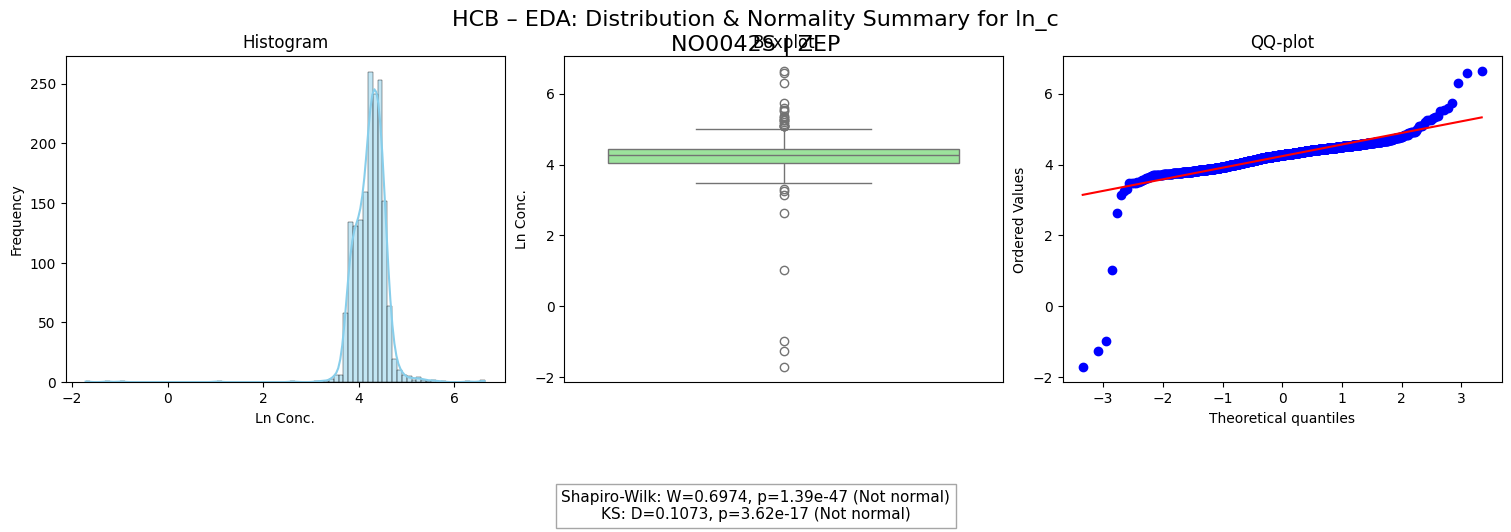

In [7]:
#5 --- EDA: DISTRIBUTION & NORMALITY ---
shapiro_stat, shapiro_p = stats.shapiro(data.ln_c)
ks_stat, ks_p = stats.kstest(data.ln_c, 'norm', args=(data.ln_c.mean(), data.ln_c.std()))
shapiro_text = f"Shapiro-Wilk: W={shapiro_stat:.4f}, p={shapiro_p:.3g} ({'Normal' if shapiro_p>0.05 else 'Not normal'})"
ks_text = f"KS: D={ks_stat:.4f}, p={ks_p:.3g} ({'Normal' if ks_p>0.05 else 'Not normal'})"
summary_text = f"{shapiro_text}\n{ks_text}"
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
sns.histplot(data.ln_c, ax=axes[0], kde=True, color='skyblue')
axes[0].set(xlabel="Ln Conc.", ylabel="Frequency", title="Histogram")
sns.boxplot(y=data.ln_c, ax=axes[1], color='lightgreen')
axes[1].set(xlabel="", ylabel="Ln Conc.", title="Boxplot")
axes[1].set_xticks([])
stats.probplot(data.ln_c, plot=axes[2])
axes[2].set_title("QQ-plot")
plt.gcf().text(0.5, -0.15, summary_text, ha='center', va='top', fontsize=11, bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray'))
plt.suptitle(f"{input_subst} – EDA: Distribution & Normality Summary for ln_c\n{station_label}", fontsize=16, y=1.05)
plt.show()
plt.close(fig)

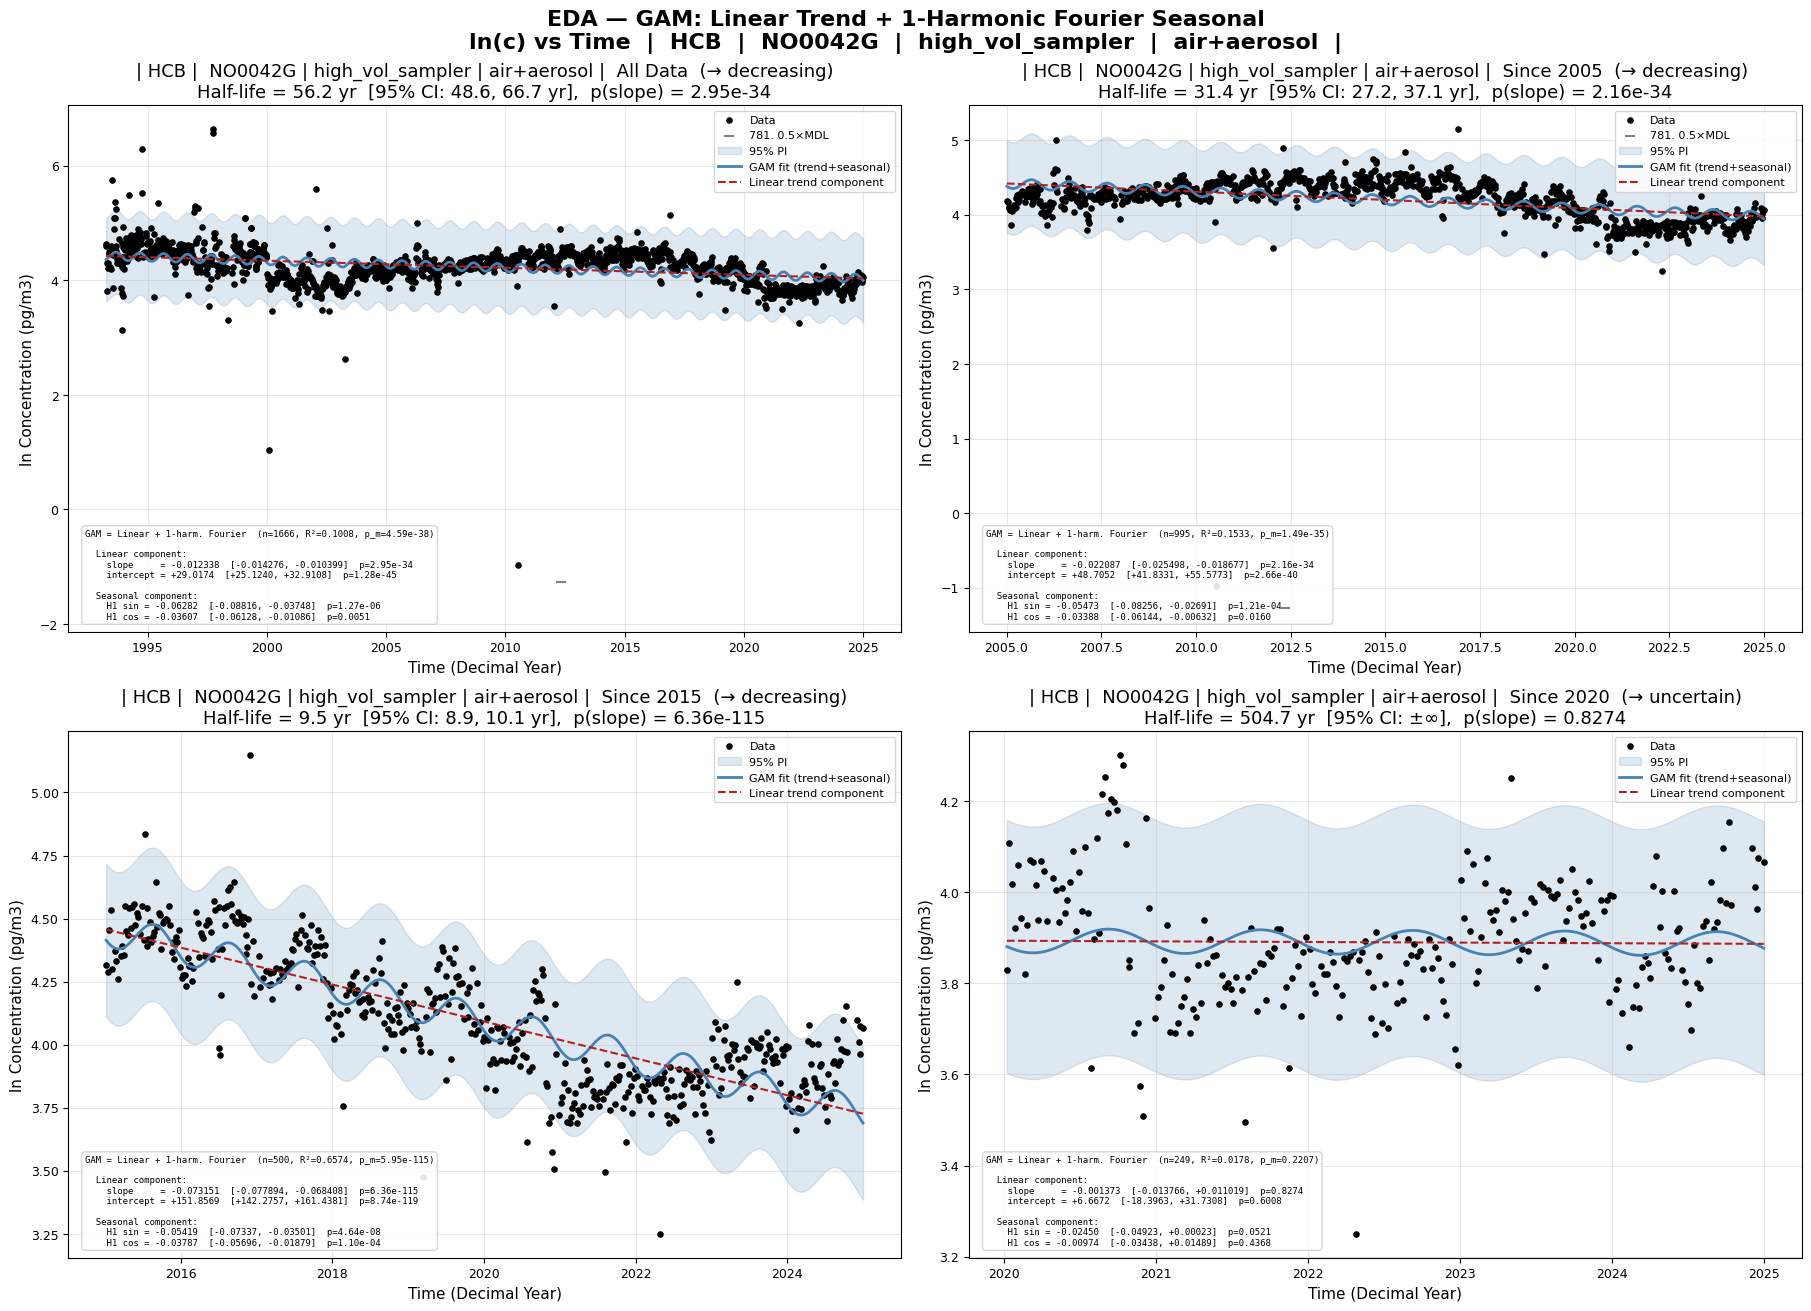

  GAM COEFFICIENT TABLES | HCB | NO0042G | high_vol_sampler | air+aerosol |

----------------------------------------------------------------------------------------------------------
  Window: All Data            n= 1666   R² = 0.100822   p_model = 4.59e-38
  Trend:  decreasing    Half-life = 56.2 yr  [95% CI: 48.6, 66.7 yr],  p(slope) = 2.95e-34
----------------------------------------------------------------------------------------------------------
  Parameter                  Coeff            SE     t-stat     p-value     95% CI lo     95% CI hi
  ------------------ ------------- ------------- ---------- ----------- ------------- -------------
  sin_h1                -0.0628214     0.0129193    -4.8626   1.268e-06    -0.0881612    -0.0374817  ***
  cos_h1                -0.0360737     0.0128533    -2.8066    0.005065    -0.0612840    -0.0108635  **
  intercept             29.0174395     1.9850172    14.6182   1.283e-45    25.1240419    32.9108370  ***
  slope                 -0.01

In [8]:
#5.5 --- EDA: GAM (Linear Trend + 1-Harmonic Fourier Seasonal) — 4 Time Windows ---
from scipy import stats as sp_stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Display settings (consistent with final visualisation cell) ─────────────
_emph_title        = 13
_emph_label        = 11
_emph_legend       = 8
_emph_tick         = 9
_small_data_marker = 14
_lbl_781_gam       = '781. 0.5×MDL' if handle_flag_781 == 'Replace' else '781. Kept as MDL'

# ────────────────────────────────────────────────────────────────────────────
# BASIS FUNCTIONS
# ────────────────────────────────────────────────────────────────────────────
def _linear_basis(t):
    """[1, t]  — intercept + slope."""
    return np.column_stack([np.ones_like(t), t])

def _fourier_basis(t, n_harmonics=1):
    """Fourier seasonal block with n_harmonics over a 1-year period."""
    omega = 2.0 * np.pi          # 1-year period in decimal-year units
    cols, labels = [], []
    for k in range(1, n_harmonics + 1):
        cols.append(np.sin(k * omega * t));  labels.append(f'sin_h{k}')
        cols.append(np.cos(k * omega * t));  labels.append(f'cos_h{k}')
    return np.column_stack(cols), labels

# ────────────────────────────────────────────────────────────────────────────
# OLS GAM FITTING
# ────────────────────────────────────────────────────────────────────────────
def _fit_gam(t, y, n_harmonics=1):
    """
    Fit  y = Fourier_seasonal(n_harmonics) + Linear(intercept, slope)  by OLS.

    Design matrix columns  →  [sin_h1, cos_h1, …, sin_hN, cos_hN, 1, t]

    Returns a dict with coefficients, SEs, t-stats, p-values, 95 % CIs,
    covariance matrix, R², overall-F p-value, and component index slices.
    """
    n = len(t)
    X_seas, seas_labels = _fourier_basis(t, n_harmonics)
    X_lin               = _linear_basis(t)
    X = np.column_stack([X_seas, X_lin])       # shape (n, 2*N+2)

    n_seas = X_seas.shape[1]
    p      = X.shape[1]

    # ── OLS ──────────────────────────────────────────────────────────────────
    coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    y_fit    = X @ coeffs
    residuals = y - y_fit
    sigma2   = np.sum(residuals ** 2) / (n - p)     # unbiased σ²

    XtX_inv  = np.linalg.pinv(X.T @ X)
    cov_mat  = sigma2 * XtX_inv                      # (p × p) covariance
    se       = np.sqrt(np.diag(cov_mat))             # standard errors

    t_stats  = coeffs / se
    p_values = 2.0 * sp_stats.t.sf(np.abs(t_stats), df=n - p)
    t_crit   = sp_stats.t.ppf(0.975, df=n - p)
    ci_lo    = coeffs - t_crit * se
    ci_hi    = coeffs + t_crit * se

    # ── R² and overall F-test ─────────────────────────────────────────────────
    ss_res   = np.sum(residuals ** 2)
    ss_tot   = np.sum((y - y.mean()) ** 2)
    r2       = 1.0 - ss_res / ss_tot
    k        = p - 1                                 # number of predictors
    F_stat   = ((ss_tot - ss_res) / k) / (ss_res / (n - p))
    p_F      = sp_stats.f.sf(F_stat, dfn=k, dfd=n - p)

    all_labels = seas_labels + ['intercept', 'slope']

    return dict(
        coeffs=coeffs, se_coeffs=se, t_stats=t_stats,
        p_values=p_values, ci_lo=ci_lo, ci_hi=ci_hi,
        cov_mat=cov_mat, sigma2=sigma2,
        r2=r2, p_overall=p_F,
        n=n, p=p, t_crit=t_crit,
        seas_slice=slice(0, n_seas),
        lin_slice=slice(n_seas, n_seas + 2),
        all_labels=all_labels,
        n_harmonics=n_harmonics,
    )

# ────────────────────────────────────────────────────────────────────────────
# PREDICTION + 95 % PREDICTION INTERVAL ON A GRID
# ────────────────────────────────────────────────────────────────────────────
def _predict_pi(t_grid, fr):
    X_s, _ = _fourier_basis(t_grid, fr['n_harmonics'])
    X_l    = _linear_basis(t_grid)
    Xg     = np.column_stack([X_s, X_l])
    y_hat  = Xg @ fr['coeffs']
    # SE of the conditional mean fit
    se_fit = np.sqrt(np.einsum('ij,jk,ik->i', Xg, fr['cov_mat'], Xg))
    se_pred = np.sqrt(se_fit ** 2 + fr['sigma2'])
    tc      = fr['t_crit']
    return y_hat, y_hat - tc * se_pred, y_hat + tc * se_pred

def _trend_only(t_grid, fr):
    """Pure linear trend component evaluated on the grid."""
    ls = fr['lin_slice']
    return fr['coeffs'][ls][0] + fr['coeffs'][ls][1] * t_grid

# ────────────────────────────────────────────────────────────────────────────
# p-VALUE FORMATTER
# ────────────────────────────────────────────────────────────────────────────
def _pfmt(p):
    return f'{p:.2e}' if p < 0.001 else f'{p:.4f}'

# ────────────────────────────────────────────────────────────────────────────
# HALF-LIFE SUMMARY (shared logic for panel title and coefficient table)
# ────────────────────────────────────────────────────────────────────────────
def _hl_info(slope, slp_lo, slp_hi, p_slp):
    """
    Return (trend_dir, hl_val, hl_ci_lo, hl_ci_hi, hl_str) from slope info.
    half-life = -ln(2)/slope  (negative slope → positive HL → decreasing).
    """
    ln2 = np.log(2)
    if p_slp >= 0.05:
        trend_dir = "uncertain"
    elif slope < 0:
        trend_dir = "decreasing"
    else:
        trend_dir = "increasing"

    hl_val  = -ln2 / slope if slope != 0 else np.nan
    hl_ci_a = -ln2 / slp_lo if slp_lo != 0 else np.nan
    hl_ci_b = -ln2 / slp_hi if slp_hi != 0 else np.nan
    ci_spans_zero = (slp_lo != 0 and slp_hi != 0 and
                     np.sign(slp_lo) != np.sign(slp_hi))

    if not np.isfinite(hl_val):
        hl_str = "n/a"
    elif ci_spans_zero or not (np.isfinite(hl_ci_a) and np.isfinite(hl_ci_b)):
        hl_str = f"{hl_val:.1f} yr  [95% CI: ±∞]"
    else:
        ci_lo_d = min(hl_ci_a, hl_ci_b)
        ci_hi_d = max(hl_ci_a, hl_ci_b)
        hl_str  = f"{hl_val:.1f} yr  [95% CI: {ci_lo_d:.1f}, {ci_hi_d:.1f} yr]"

    return trend_dir, hl_val, hl_ci_a, hl_ci_b, hl_str

# ────────────────────────────────────────────────────────────────────────────
# HALF-LIFE TITLE BUILDER
# ────────────────────────────────────────────────────────────────────────────
def _half_life_title(slope, slp_lo, slp_hi, p_slp, window_label):
    trend_dir, _, _, _, hl_str = _hl_info(slope, slp_lo, slp_hi, p_slp)
    line1 = f"| {input_subst} |  {station_code} | {instrument_type} | {matrix} |  {window_label}  (→ {trend_dir})"
    line2 = f"Half-life = {hl_str},  p(slope) = {_pfmt(p_slp)}"
    return f"{line1}\n{line2}"

# ────────────────────────────────────────────────────────────────────────────
# SINGLE PANEL PLOTTER
# ────────────────────────────────────────────────────────────────────────────
def _gam_panel(ax, subset, window_label, n_harmonics=1):
    t_arr = subset['time_y'].values.astype(float)
    y_arr = subset['ln_c'].values.astype(float)
    valid = np.isfinite(t_arr) & np.isfinite(y_arr)
    t_arr, y_arr = t_arr[valid], y_arr[valid]
    sub_v = subset.loc[subset.index[valid]]

    if len(t_arr) < 10:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes,
                ha='center', va='center', fontsize=_emph_label)
        ax.set_title(f"|  {input_subst}  |  {station_code}  |  {instrument_type}  |  {matrix}  |  {window_label}\n{station_label}",
                     fontsize=_emph_title)
        return None

    fr = _fit_gam(t_arr, y_arr, n_harmonics)

    # Smooth prediction grid
    t_grid = np.linspace(t_arr.min(), t_arr.max(), 500)
    y_hat, pi_lo, pi_hi = _predict_pi(t_grid, fr)
    trend = _trend_only(t_grid, fr)

    # ── MDL flag masks ────────────────────────────────────────────────────────
    _has_780 = 'flag_780' in sub_v.columns and sub_v['flag_780'].any()
    _has_781 = 'flag_781' in sub_v.columns and sub_v['flag_781'].any()
    unflagged = pd.Series(True, index=sub_v.index)
    if 'flag_780' in sub_v.columns: unflagged &= ~sub_v['flag_780']
    if 'flag_781' in sub_v.columns: unflagged &= ~sub_v['flag_781']

    # ── Scatter (data) ────────────────────────────────────────────────────────
    ax.scatter(sub_v.loc[unflagged, 'time_y'], sub_v.loc[unflagged, 'ln_c'],
               c='black', s=_small_data_marker, label='Data', zorder=3)
    if _has_780:
        ax.scatter(sub_v.loc[sub_v['flag_780'], 'time_y'],
                   sub_v.loc[sub_v['flag_780'], 'ln_c'],
                   marker='<', facecolors='none', edgecolors='gray',
                   s=_small_data_marker * 2, zorder=5,
                   label='780. <MDL but reported')
    if _has_781:
        ax.scatter(sub_v.loc[sub_v['flag_781'], 'time_y'],
                   sub_v.loc[sub_v['flag_781'], 'ln_c'],
                   marker='_', c='gray', s=_small_data_marker * 4,
                   linewidths=1.5, zorder=5, label=_lbl_781_gam)

    # ── GAM fit + 95 % PI ─────────────────────────────────────────────────────
    ax.fill_between(t_grid, pi_lo, pi_hi,
                    color='steelblue', alpha=0.18, label='95% PI')
    ax.plot(t_grid, y_hat,  color='steelblue', linewidth=2.0,
            label='GAM fit (trend+seasonal)', zorder=4)
    ax.plot(t_grid, trend, color='firebrick', linewidth=1.5,
            linestyle='--', label='Linear trend component', zorder=5)

    # ── Compact in-plot annotation ────────────────────────────────────────────
    c, ce, pv = fr['coeffs'], fr['se_coeffs'], fr['p_values']
    ci_l, ci_h = fr['ci_lo'], fr['ci_hi']
    ls, ss = fr['lin_slice'], fr['seas_slice']
    intercept, slope = c[ls][0], c[ls][1]
    p_int,  p_slp    = pv[ls][0], pv[ls][1]
    slp_lo, slp_hi   = ci_l[ls][1], ci_h[ls][1]
    int_lo, int_hi   = ci_l[ls][0], ci_h[ls][0]
    seas_c   = c[ss]
    seas_cil = ci_l[ss]
    seas_cih = ci_h[ss]
    seas_pv  = pv[ss]

    lines = [
        f"GAM = Linear + {n_harmonics}-harm. Fourier  "
        f"(n={fr['n']}, R²={fr['r2']:.4f}, p_m={_pfmt(fr['p_overall'])})",
        "",
        f"  Linear component:",
        f"    slope     = {slope:+.6f}  [{slp_lo:+.6f}, {slp_hi:+.6f}]  p={_pfmt(p_slp)}",
        f"    intercept = {intercept:+.4f}  [{int_lo:+.4f}, {int_hi:+.4f}]  p={_pfmt(p_int)}",
        "",
        f"  Seasonal component:",
    ]
    for k in range(n_harmonics):
        si, ci_i = 2 * k, 2 * k + 1
        lines.append(
            f"    H{k+1} sin = {seas_c[si]:+.5f}  [{seas_cil[si]:+.5f}, {seas_cih[si]:+.5f}]"
            f"  p={_pfmt(seas_pv[si])}"
        )
        lines.append(
            f"    H{k+1} cos = {seas_c[ci_i]:+.5f}  [{seas_cil[ci_i]:+.5f}, {seas_cih[ci_i]:+.5f}]"
            f"  p={_pfmt(seas_pv[ci_i])}"
        )

    ax.text(0.02, 0.02, "\n".join(lines), transform=ax.transAxes,
            fontsize=6.5, va='bottom', ha='left', family='monospace',
            bbox=dict(facecolor='white', alpha=0.90, edgecolor='lightgray',
                      boxstyle='round,pad=0.35'))

    # ── Axes decoration ───────────────────────────────────────────────────────
    ax.set_title(_half_life_title(slope, slp_lo, slp_hi, p_slp, window_label),
                 fontsize=_emph_title)
    ax.set_xlabel('Time (Decimal Year)', fontsize=_emph_label)
    ax.set_ylabel(f'ln Concentration ({ts.attrs.get("units", "")})', fontsize=_emph_label)
    ax.tick_params(axis='both', labelsize=_emph_tick)
    ax.legend(fontsize=_emph_legend, loc='upper right')
    ax.grid(True, alpha=0.30)
    return fr

# ────────────────────────────────────────────────────────────────────────────
# DEFINE FOUR TIME WINDOWS AND RUN
# ────────────────────────────────────────────────────────────────────────────
_windows_gam = [
    (None,   'All Data'),
    (2005.0, 'Since 2005'),
    (2015.0, 'Since 2015'),
    (2020.0, 'Since 2020'),
]

fig_gam, axes_gam = plt.subplots(2, 2, figsize=(18, 13), constrained_layout=True)

_fit_results_gam = {}
for ax, (t_start, lbl) in zip(axes_gam.flatten(), _windows_gam):
    sub = (data.copy() if t_start is None
           else data.loc[data['time_y'] >= t_start].copy())
    fr  = _gam_panel(ax, sub, lbl)
    if fr is not None:
        _fit_results_gam[lbl] = fr

fig_gam.suptitle(
    f"EDA — GAM: Linear Trend + 1-Harmonic Fourier Seasonal\n"
    f"ln(c) vs Time  |  {input_subst}  |  {station_code}  |  {instrument_type}  |  {matrix}  |",
    fontsize=_emph_title + 3, fontweight='bold'
)
plt.show()
save_plot(fig_gam, f'Exploratory_GAM_LinearFourier_{_label_fn}')

# ────────────────────────────────────────────────────────────────────────────
# PRINT FULL COEFFICIENT TABLES
# ────────────────────────────────────────────────────────────────────────────
_W = 106
gam_coeff_lines = []
gam_coeff_lines.append("=" * _W)
gam_coeff_lines.append(f"  GAM COEFFICIENT TABLES | {input_subst} | {station_code} | {instrument_type} | {matrix} |")
gam_coeff_lines.append("=" * _W)
for lbl, fr in _fit_results_gam.items():
    # ── Extract slope info ────────────────────────────────────────────────────
    _ls    = fr['lin_slice']
    _slope = fr['coeffs'][_ls][1]
    _sl_lo = fr['ci_lo'][_ls][1]
    _sl_hi = fr['ci_hi'][_ls][1]
    _p_slp = fr['p_values'][_ls][1]
    _trend_dir, _, _, _, _hl_str = _hl_info(_slope, _sl_lo, _sl_hi, _p_slp)

    gam_coeff_lines.append(f"\n{'-'*_W}")
    gam_coeff_lines.append(f"  Window: {lbl:<18}  n={fr['n']:>5}   "
          f"R² = {fr['r2']:.6f}   p_model = {_pfmt(fr['p_overall'])}")
    gam_coeff_lines.append(f"  Trend:  {_trend_dir:<12}  "
          f"Half-life = {_hl_str},  p(slope) = {_pfmt(_p_slp)}")
    gam_coeff_lines.append(f"{'-'*_W}")
    hdr = f"  {'Parameter':<18} {'Coeff':>13} {'SE':>13} {'t-stat':>10} "  \
          f"{'p-value':>11} {'95% CI lo':>13} {'95% CI hi':>13}"
    gam_coeff_lines.append(hdr)
    gam_coeff_lines.append(f"  {'-'*18} {'-'*13} {'-'*13} {'-'*10} {'-'*11} {'-'*13} {'-'*13}")
    for i, lname in enumerate(fr['all_labels']):
        sig = ('***' if fr['p_values'][i] < 0.001 else
               '**'  if fr['p_values'][i] < 0.01  else
               '*'   if fr['p_values'][i] < 0.05  else '')
        gam_coeff_lines.append(f"  {lname:<18} {fr['coeffs'][i]:>13.7f} {fr['se_coeffs'][i]:>13.7f} "
              f"{fr['t_stats'][i]:>10.4f} {fr['p_values'][i]:>11.4g} "
              f"{fr['ci_lo'][i]:>13.7f} {fr['ci_hi'][i]:>13.7f}  {sig}")
gam_coeff_lines.append(f"\n{'='*_W}")
gam_coeff_lines.append("  Significance codes:  *** p < 0.001   ** p < 0.01   * p < 0.05")
gam_coeff_lines.append("=" * _W)

gam_coeff_text = "\n".join(gam_coeff_lines)
# Print to console for visibility
print(gam_coeff_text)
# Save to file
save_text(gam_coeff_text, f'Exploratory_GAM_Coefficient_Tables_{_label_fn}')



 Data-Driven PELT Parameters:
   n=1666, log₂(n)=10.70
   min_size=5, pen=5.35, jump=5


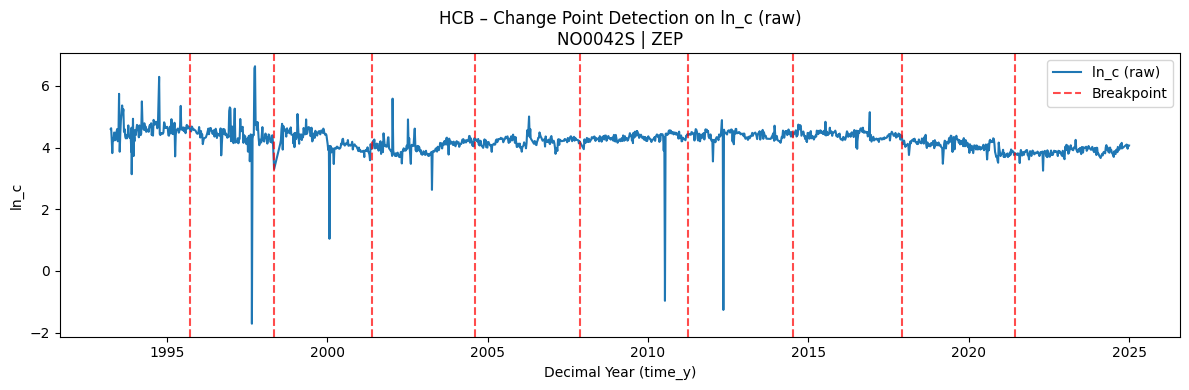

✓ Detected 9 breakpoints (by decimal year) [raw]:
 Breakpoint #  Decimal Year
            1   1995.720548
            2   1998.346119
            3   2001.411872
            4   2004.607468
            5   2007.866700
            6   2011.239692
            7   2014.515949
            8   2017.908016
            9   2021.433830

Raw data breakpoints saved to breaks_df_raw


In [9]:
#6 --- CHANGE POINT DETECTION (RAW DATA) ---
from splinter_functions import *

# Detect changepoints in RAW data (pen=5)
result_raw = detect_changepoints(data_df=data, 
                                 data_label='raw', 
                                 use_data_driven=True, # automatically calculate attributes based on data sizes
                                 input_subst=input_subst, 
                                 station_label=station_label, 
                                 visualization=True,
                                 )
breaks_df_raw = result_raw['breaks_df']
print("Raw data breakpoints saved to breaks_df_raw")

GAM DECOMPOSITION WITH ITERATIVE MODEL SELECTION (Model1: Raw Data)
Time span: 31.75 years
Number of observations: 1666
Time range: 1993.25 to 2025.00

Testing 3 seasonal harmonic options
Testing 1 valid knot configurations
Total models to evaluate: 3
  Model failed (h=0, k=0): cannot unpack non-iterable NoneType object

✓ Fitted 2 models successfully in 0.007 seconds

TOP 10 MODELS BY BIC (Model1)
Rank   Harmonics    Knots    BIC          R²         RMSE      
--------------------------------------------------------------------------------
1      1            0        -3270.69     0.100822   0.371389  
2      2            0        -3263.01     0.104673   0.370593  

BEST MODEL SELECTED (Model1)
Seasonal harmonics (1-year period): 1
Spline knots: 0
Total parameters: 4
BIC: -3270.69
AIC: -3292.37
R²: 0.100822
RMSE: 0.371389

CALCULATING 95% CONFIDENCE INTERVALS (Model1)
✓ 95% confidence intervals calculated for Model1
  Critical t-value (df=1662): 1.9614

DETAILED COMPONENT ANALYSIS (Mo

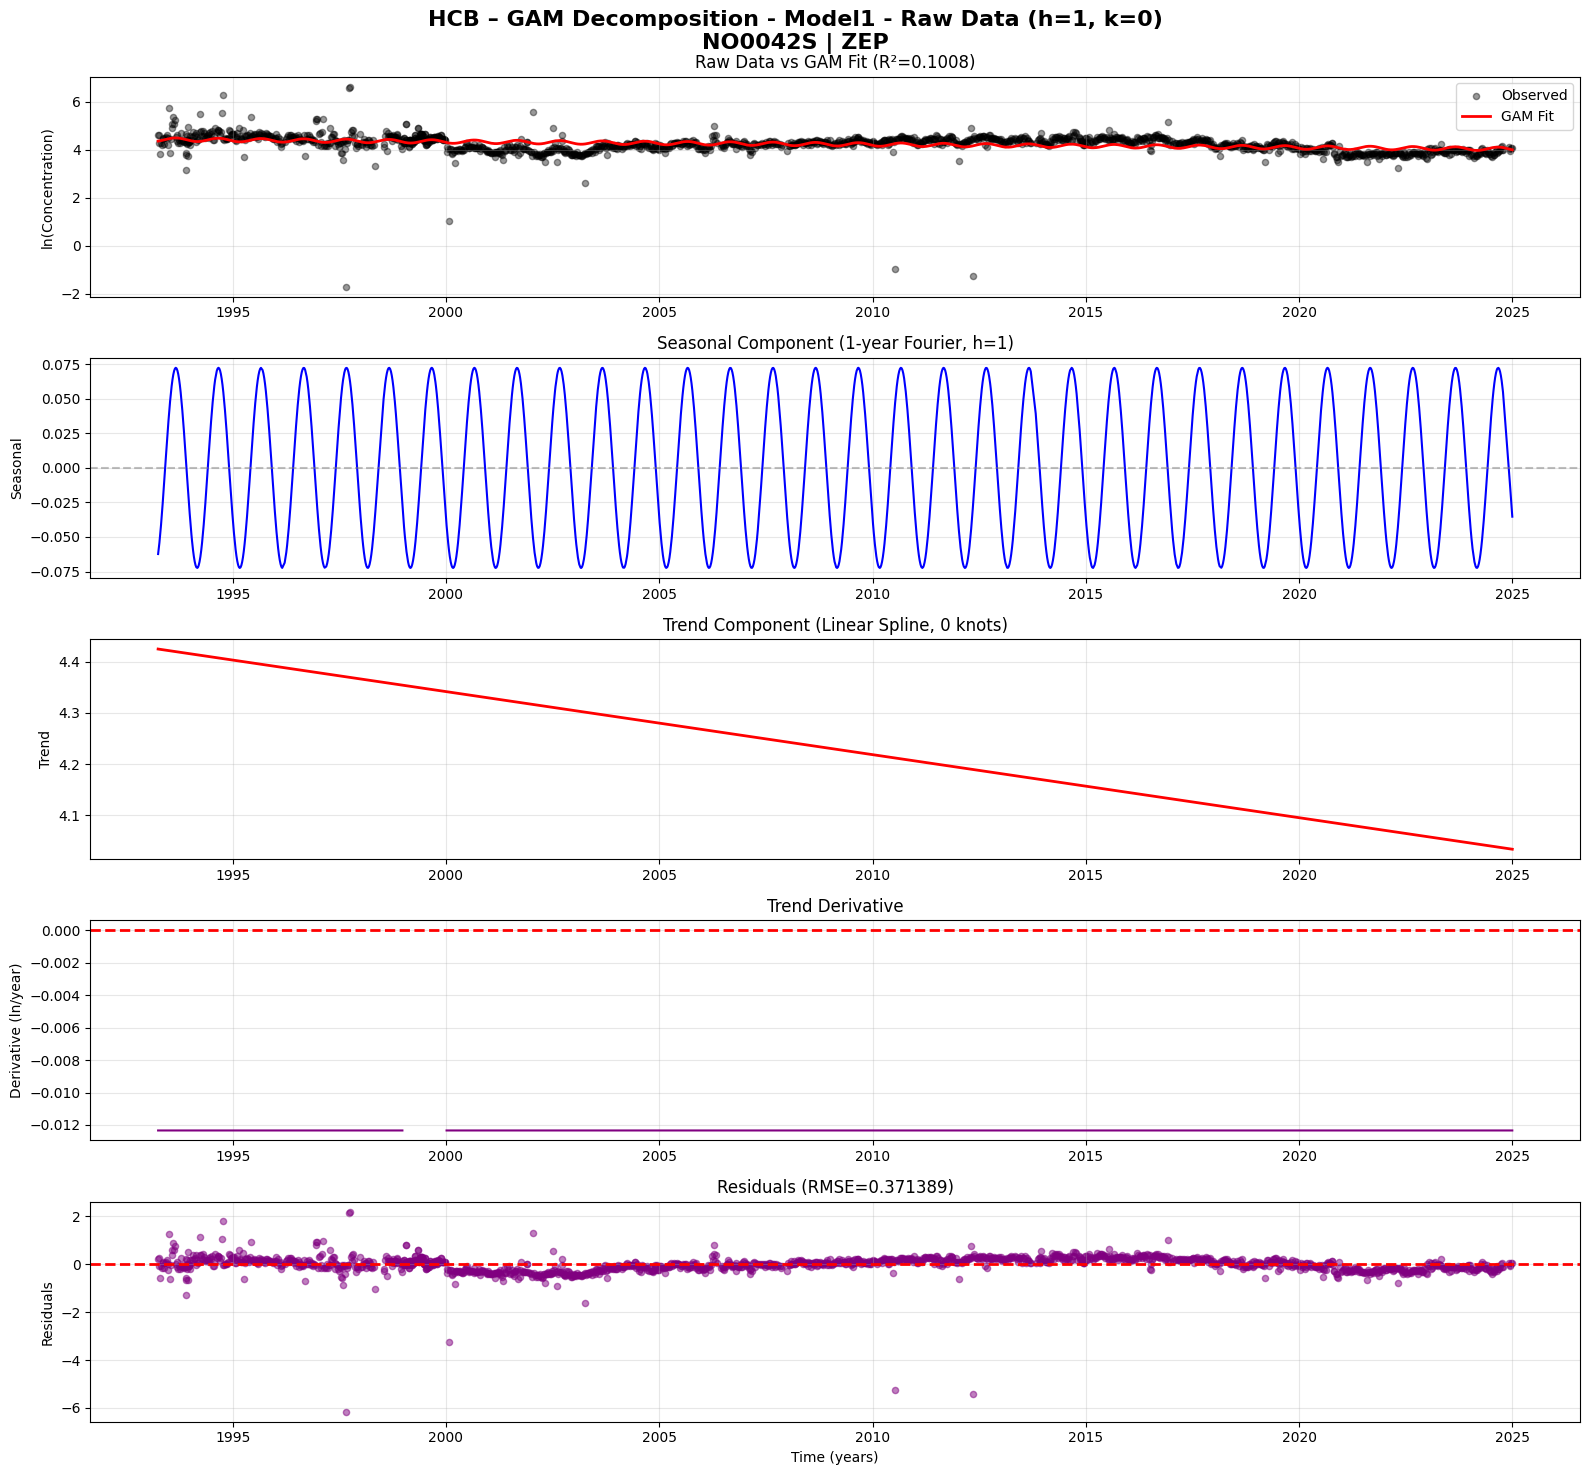

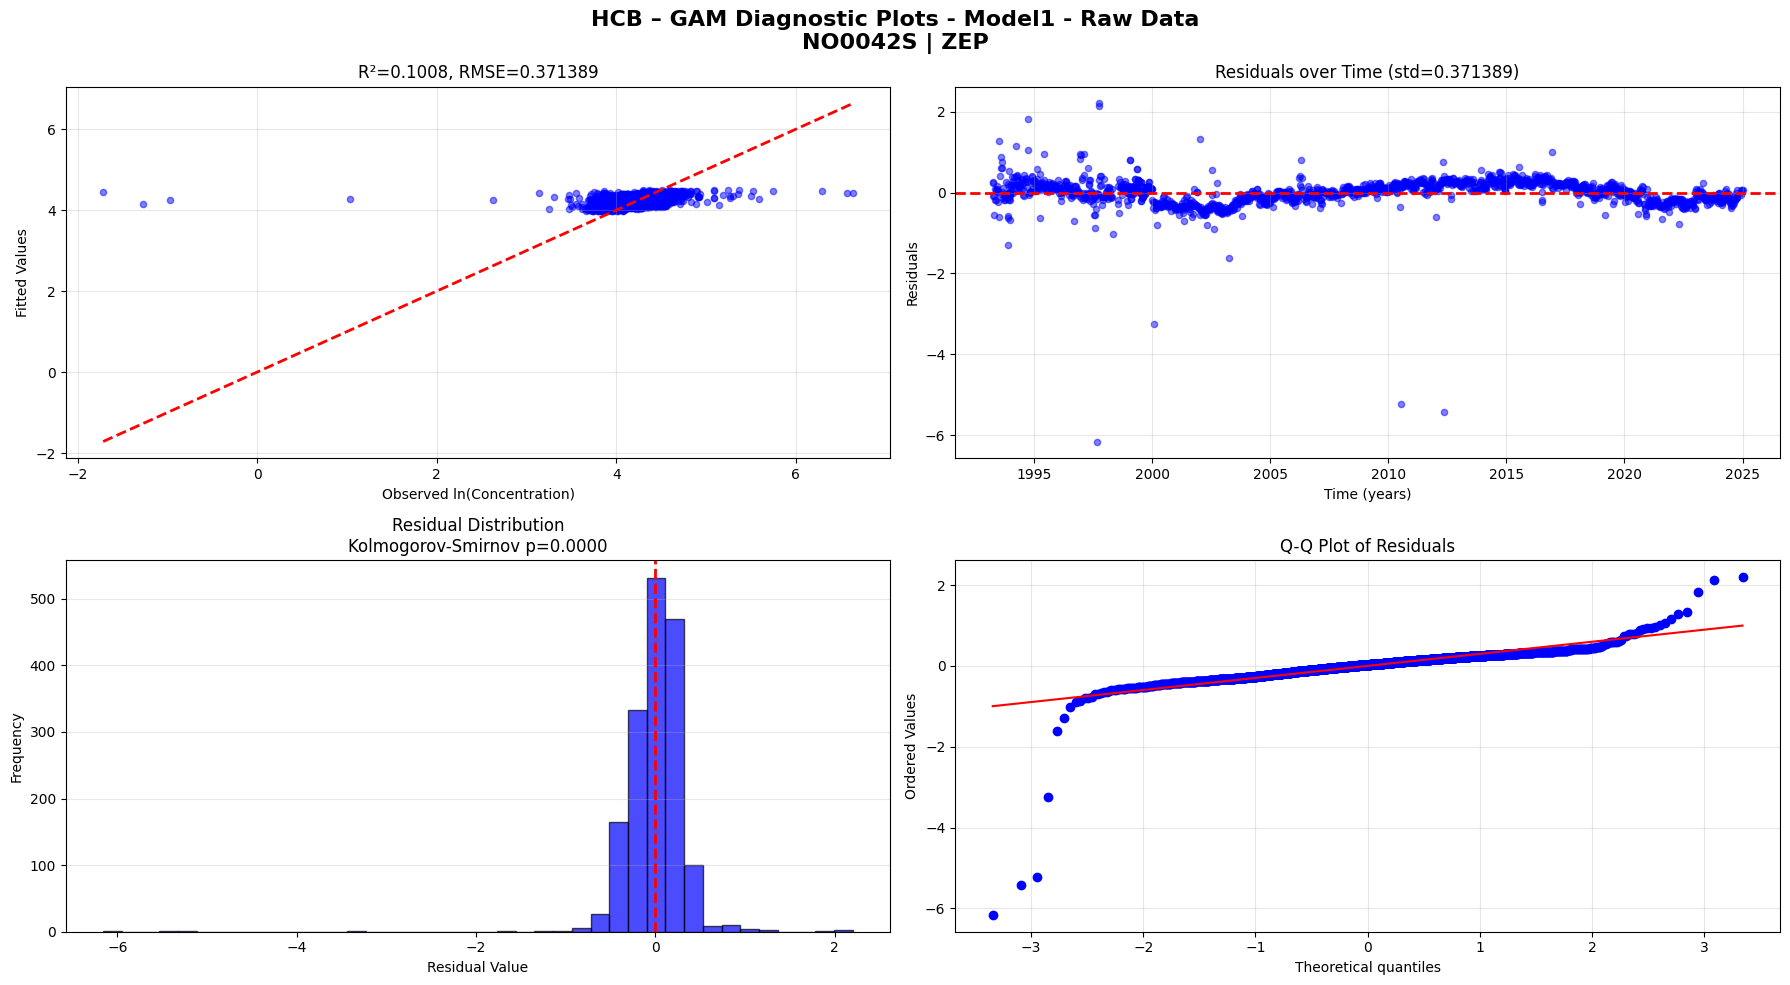


RESIDUALS SAVED TO DATA DATAFRAME (Model1)
Column 'Model1_residuals' added to data dataframe
Non-NaN values: 1666

SUMMARY (Model1)
✓ Model components:
  - Seasonal: 1-year Fourier with 1 harmonics
  - Trend: Linear spline with 0 knots
✓ Model performance:
  - BIC: -3270.69
  - R²: 0.100822
  - RMSE: 0.371389
✓ Execution time: 0.007 seconds


In [10]:
#7 GAM Model1 (Raw Data)
import time
import warnings
from itertools import product
warnings.filterwarnings('ignore')

data, best_model1 = run_gam_model(
    data_df=data,
    model_name='Model1',
    data_description='Raw Data',
    input_subst=input_subst,
    station_label=station_label,
    station_label_fn=station_label_fn,
    MaxKnotPeriod=MaxKnotPeriod,
    MinKnotInterval=MinKnotInterval,
    StartPad=StartPad,
    EndPad=EndPad,
    LastKnotYear=LastKnotYear,
    _user_EndPad=_user_EndPad,
    harmonics_range=[0, 1, 2],
    save_plots=False
)

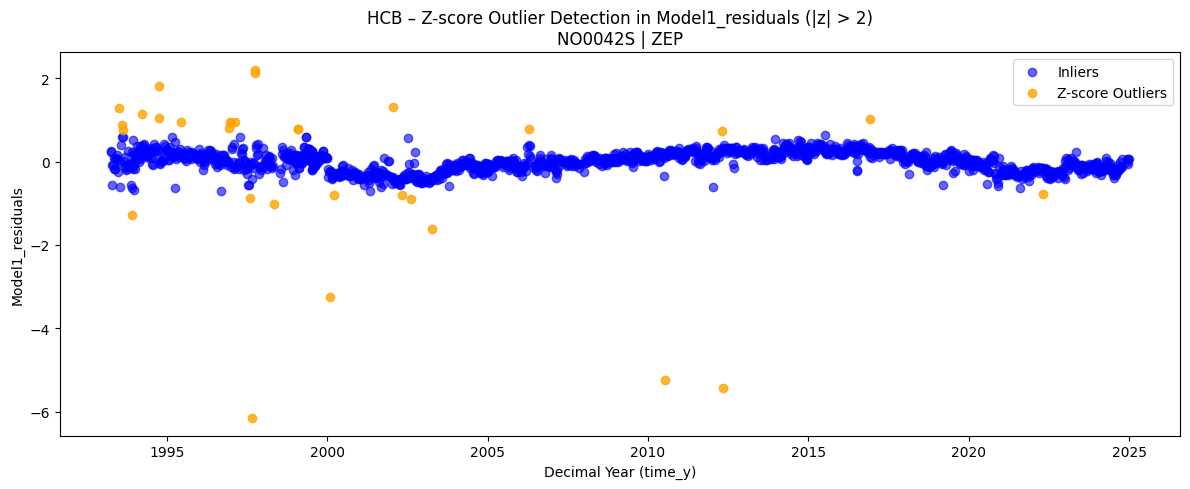

In [11]:
#8 --- OUTLIER DETECTION & REMOVAL ---
from scipy.stats import zscore
valid_mask = data['Model1_residuals'].notna()
residuals = data.loc[valid_mask, 'Model1_residuals'].values
n = len(residuals)
z_thresh = 3 if n <= 333 else 2.5 if n <= 1000 else 2
z_scores = zscore(residuals)
z_outlier_mask = np.abs(z_scores) > z_thresh
data['Model1_z_outlier'] = False
data.loc[valid_mask, 'Model1_z_outlier'] = z_outlier_mask
fig, ax = plt.subplots(figsize=(12, 5))
x = data.loc[valid_mask, 'time_y'].values
ax.scatter(x[~z_outlier_mask], residuals[~z_outlier_mask], c='blue', label='Inliers', alpha=0.6)
ax.scatter(x[z_outlier_mask], residuals[z_outlier_mask], c='orange', label='Z-score Outliers', alpha=0.8)
ax.set_xlabel('Decimal Year (time_y)')
ax.set_ylabel('Model1_residuals')
ax.set_title(f'{input_subst} – Z-score Outlier Detection in Model1_residuals (|z| > {z_thresh})\n{station_label}')
ax.legend()
plt.tight_layout()
plt.show()
#save_plot(fig, f"OutlierDetection_Zscore_{input_subst}_{station_label_fn}")
data_clean = data[~data['Model1_z_outlier']].reset_index(drop=True)
#save_df(data_clean, f"Data_Cleaned_{input_subst}_{station_label_fn}")


 Data-Driven PELT Parameters:
   n=1635, log₂(n)=10.68
   min_size=5, pen=5.34, jump=5


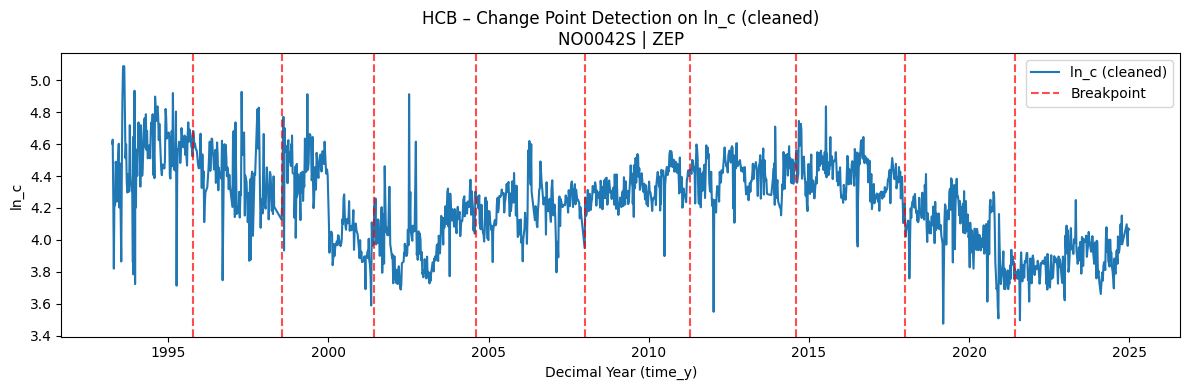

✓ Detected 9 breakpoints (by decimal year) [cleaned]:
 Breakpoint #  Decimal Year
            1   1995.778082
            2   1998.557078
            3   2001.431050
            4   2004.607468
            5   2007.999996
            6   2011.297144
            7   2014.592649
            8   2018.003765
            9   2021.433830

Cleaned data breakpoints saved to breaks_df_clean


In [12]:
#10 --- CHANGE POINT DETECTION (CLEANED DATA) ---
# result_clean = detect_changepoints(data_clean, data_label='cleaned', pen_value=3, do_plot=True)
result_clean = detect_changepoints(data_df=data_clean, 
                                   data_label='cleaned', 
                                   use_data_driven=True, # automatically calculate attributes based on data sizes
                                   input_subst=input_subst, 
                                   station_label=station_label, 
                                   visualization=True)
breaks_df_clean = result_clean['breaks_df']
print("Cleaned data breakpoints saved to breaks_df_clean")

GAM DECOMPOSITION WITH ITERATIVE MODEL SELECTION (Model2: Cleaned Data)
Time span: 31.75 years
Number of observations: 1635
Time range: 1993.25 to 2025.00

Testing 3 seasonal harmonic options
Testing 1 valid knot configurations
Total models to evaluate: 3
  Model failed (h=0, k=0): cannot unpack non-iterable NoneType object

✓ Fitted 2 models successfully in 0.001 seconds

TOP 10 MODELS BY BIC (Model2)
Rank   Harmonics    Knots    BIC          R²         RMSE      
--------------------------------------------------------------------------------
1      2            0        -4752.63     0.215538   0.230621  
2      1            0        -4752.32     0.208253   0.231689  

BEST MODEL SELECTED (Model2)
Seasonal harmonics (1-year period): 2
Spline knots: 0
Total parameters: 6
BIC: -4752.63
AIC: -4785.03
R²: 0.215538
RMSE: 0.230621

CALCULATING 95% CONFIDENCE INTERVALS (Model2)
✓ 95% confidence intervals calculated for Model2
  Critical t-value (df=1629): 1.9614

DETAILED COMPONENT ANALYSIS

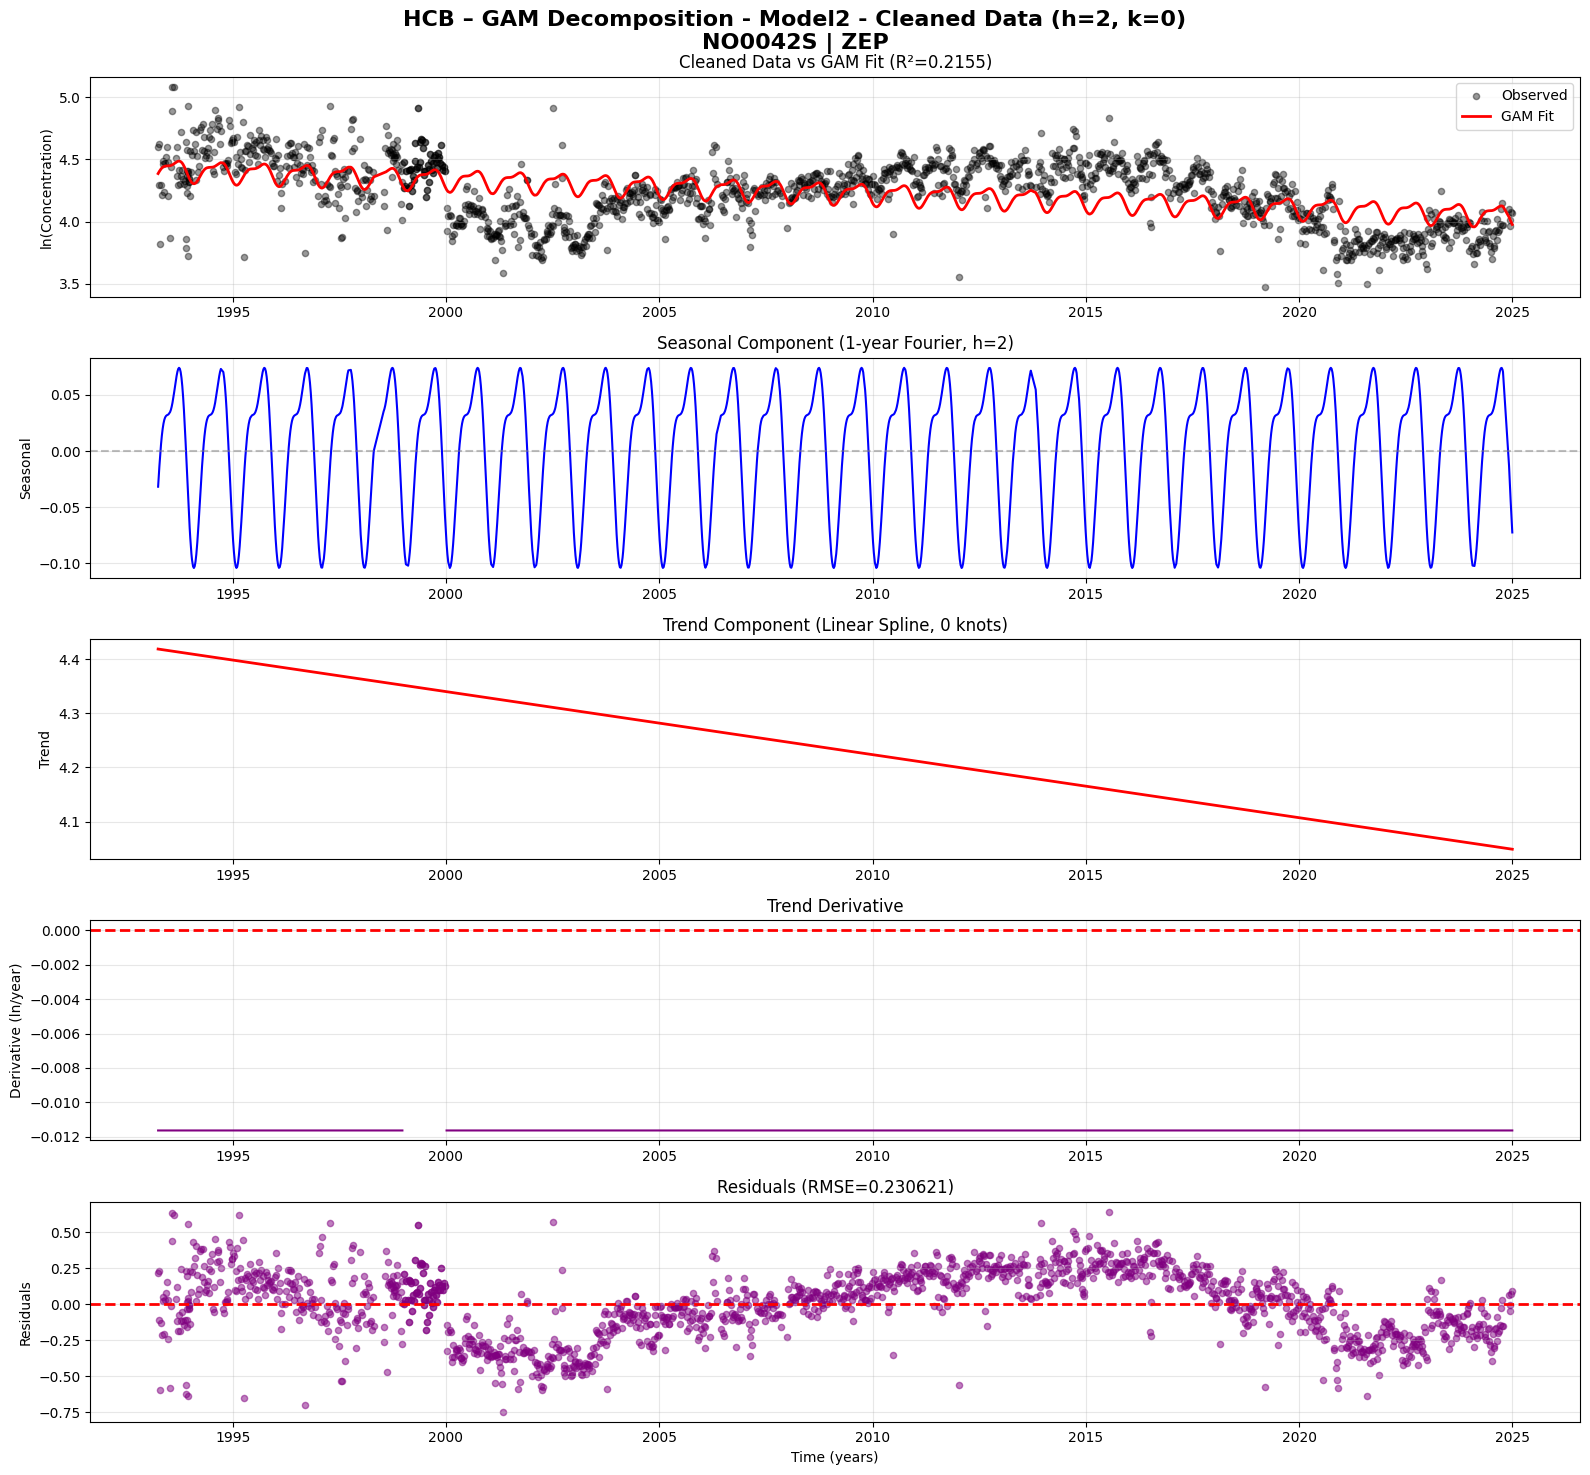

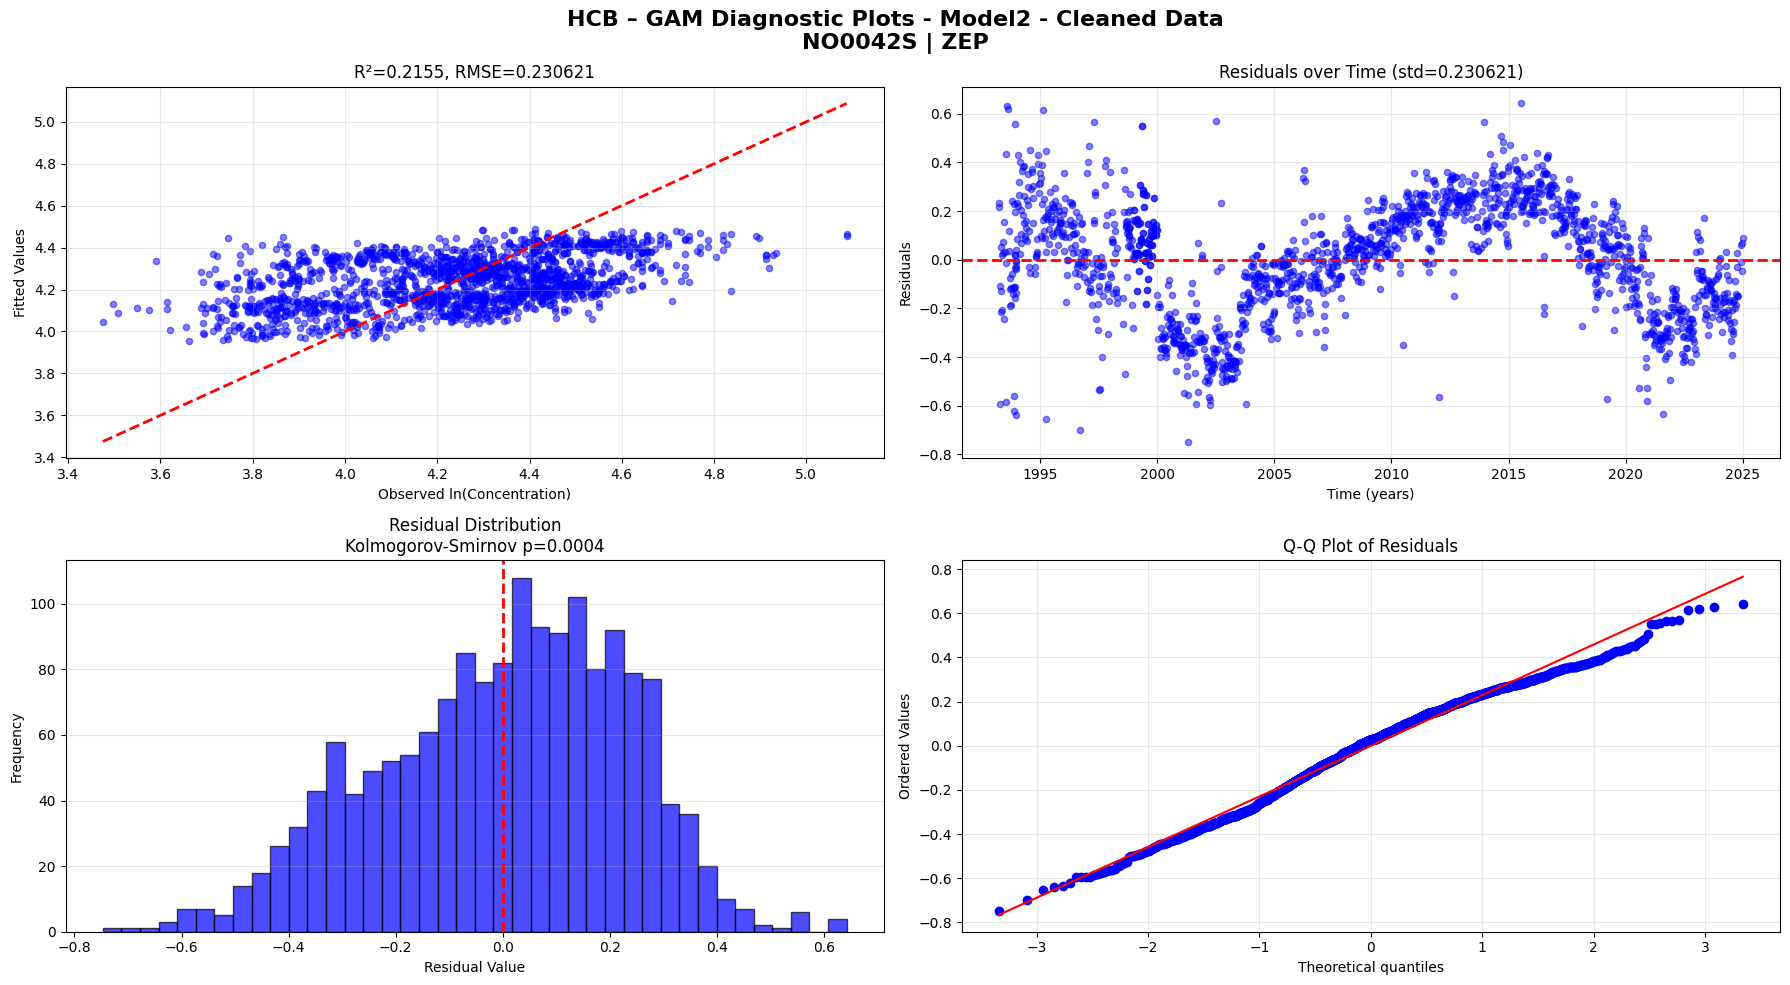


RESIDUALS SAVED TO DATA DATAFRAME (Model2)
Column 'Model2_residuals' added to data dataframe
Non-NaN values: 1635

SUMMARY (Model2)
✓ Model components:
  - Seasonal: 1-year Fourier with 2 harmonics
  - Trend: Linear spline with 0 knots
✓ Model performance:
  - BIC: -4752.63
  - R²: 0.215538
  - RMSE: 0.230621
✓ Execution time: 0.001 seconds


In [13]:
#11 GAM Model 2 (Cleaned Data)
if 'data_clean' not in globals():
    raise ValueError("data_clean not found. Please run the outlier removal step first.")

from splinter_functions import generate_valid_knot_configurations
t2 = data_clean['time_y'].values
time_span2 = t2.max() - t2.min()
valid_knot_configs = generate_valid_knot_configurations(t2, time_span2)
harmonics_range = [0, 1, 2]
total_models = len(harmonics_range) * len(valid_knot_configs)

data_clean, best_model2 = run_gam_model(
    data_df=data_clean,
    model_name='Model2',
    data_description='Cleaned Data',
    input_subst=input_subst,
    station_label=station_label,
    station_label_fn=station_label_fn,
    MaxKnotPeriod=MaxKnotPeriod,
    MinKnotInterval=MinKnotInterval,
    StartPad=StartPad,
    EndPad=EndPad,
    LastKnotYear=LastKnotYear,
    _user_EndPad=_user_EndPad,
    harmonics_range=harmonics_range,
    save_plots=False
)

In [14]:
# 12 ---  Output GAM Model plots and Final Model1 and Model 2 Results  ---

def calculate_slope(arr, time_arr):

    slope = np.full(len(arr), np.nan)

    for i in range(len(arr)):
        if i == 0:
            slope[i] = (arr[i+1] - arr[i]) / (time_arr[i+1] - time_arr[i])
        elif i == len(arr) - 1:
            slope[i] = (arr[i] - arr[i-1]) / (time_arr[i] - time_arr[i-1])
        else:
            slope[i] = (arr[i+1] - arr[i-1]) / (time_arr[i+1] - time_arr[i-1])
    return slope

# Calculate Model1 results and components for all rows in data

Model1_result = np.full(len(data), np.nan)

Model1_trend = np.full(len(data), np.nan)

Model1_trend_slope = np.full(len(data), np.nan)

Model1_seasonal = np.full(len(data), np.nan)

Model1_seasonal_slope = np.full(len(data), np.nan)

Model1_slope = np.full(len(data), np.nan)

Model1_result[data.index] = best_model1['y_pred']

Model1_trend[data.index] = best_model1['components']['trend']

Model1_trend_slope[data.index] = calculate_slope(best_model1['components']['trend'], data['time_y'].values)

Model1_seasonal[data.index] = best_model1['components']['seasonal']

Model1_seasonal_slope[data.index] = calculate_slope(best_model1['components']['seasonal'], data['time_y'].values)

for i in data.index:
    if i == data.index[0]:
        Model1_slope[i] = (Model1_trend[data.index[1]] - Model1_trend[i]) / (data['time_y'].iloc[data.index[1]] - data['time_y'].iloc[i])
    elif i == data.index[-1]:
        Model1_slope[i] = (Model1_trend[i] - Model1_trend[data.index[-2]]) / (data['time_y'].iloc[i] - data['time_y'].iloc[data.index[-2]])
    else:
        prev_idx = data.index[data.index.get_loc(i)-1]
        next_idx = data.index[data.index.get_loc(i)+1]
        Model1_slope[i] = (Model1_trend[next_idx] - Model1_trend[prev_idx]) / (data['time_y'].iloc[next_idx] - data['time_y'].iloc[prev_idx])

data['Model1_result'] = Model1_result

data['Model1_trend'] = Model1_trend

data['Model1_trend_slope'] = Model1_trend_slope

data['Model1_seasonal'] = Model1_seasonal

data['Model1_seasonal_slope'] = Model1_seasonal_slope

data['Model1_slope'] = Model1_slope

# Calculate Model2 results and components for only the subset of data_clean

Model2_result = np.full(len(data), np.nan)

Model2_trend = np.full(len(data), np.nan)

Model2_trend_slope = np.full(len(data), np.nan)

Model2_seasonal = np.full(len(data), np.nan)

Model2_seasonal_slope = np.full(len(data), np.nan)

Model2_slope = np.full(len(data), np.nan)

idx_clean = data_clean.index

Model2_result[idx_clean] = best_model2['y_pred']

Model2_trend[idx_clean] = best_model2['components']['trend']

Model2_trend_slope[idx_clean] = calculate_slope(best_model2['components']['trend'], data_clean['time_y'].values)

Model2_seasonal[idx_clean] = best_model2['components']['seasonal']

Model2_seasonal_slope[idx_clean] = calculate_slope(best_model2['components']['seasonal'], data_clean['time_y'].values)

for i in idx_clean:
    loc = list(idx_clean).index(i)
    if loc == 0:
        Model2_slope[i] = (Model2_trend[idx_clean[1]] - Model2_trend[i]) / (data['time_y'].iloc[idx_clean[1]] - data['time_y'].iloc[i])
    elif loc == len(idx_clean) - 1:
        Model2_slope[i] = (Model2_trend[i] - Model2_trend[idx_clean[-2]]) / (data['time_y'].iloc[i] - data['time_y'].iloc[idx_clean[-2]])
    else:
        prev_idx = idx_clean[loc-1]
        next_idx = idx_clean[loc+1]
        Model2_slope[i] = (Model2_trend[next_idx] - Model2_trend[prev_idx]) / (data['time_y'].iloc[next_idx] - data['time_y'].iloc[prev_idx])

data['Model2_result'] = Model2_result

data['Model2_trend'] = Model2_trend

data['Model2_trend_slope'] = Model2_trend_slope

data['Model2_seasonal'] = Model2_seasonal

data['Model2_seasonal_slope'] = Model2_seasonal_slope

data['Model2_slope'] = Model2_slope

# --- Ensure all plots are saved and save final data dataframe ---

if save_outputs:
    #save_df(data, f'Final_Data_DataFrame_{input_subst}_{station_label_fn}')
    print(f"Final data dataframe saved to: {os.path.join(output_dir, f'Final_Data_DataFrame_{input_subst}_{station_label_fn}.csv')}")
else:
    print("Output saving is disabled. Plots and data not saved.")

Final data dataframe saved to: c:\XiaoyuGithub\SPLINTER\SPLINTER\outputdirs\NO0042G_HCB_high_vol_sampler_air+aerosol_output_SPLINTER_V012_20260602_132435\Final_Data_DataFrame_HCB_NO0042S_ZEP.csv


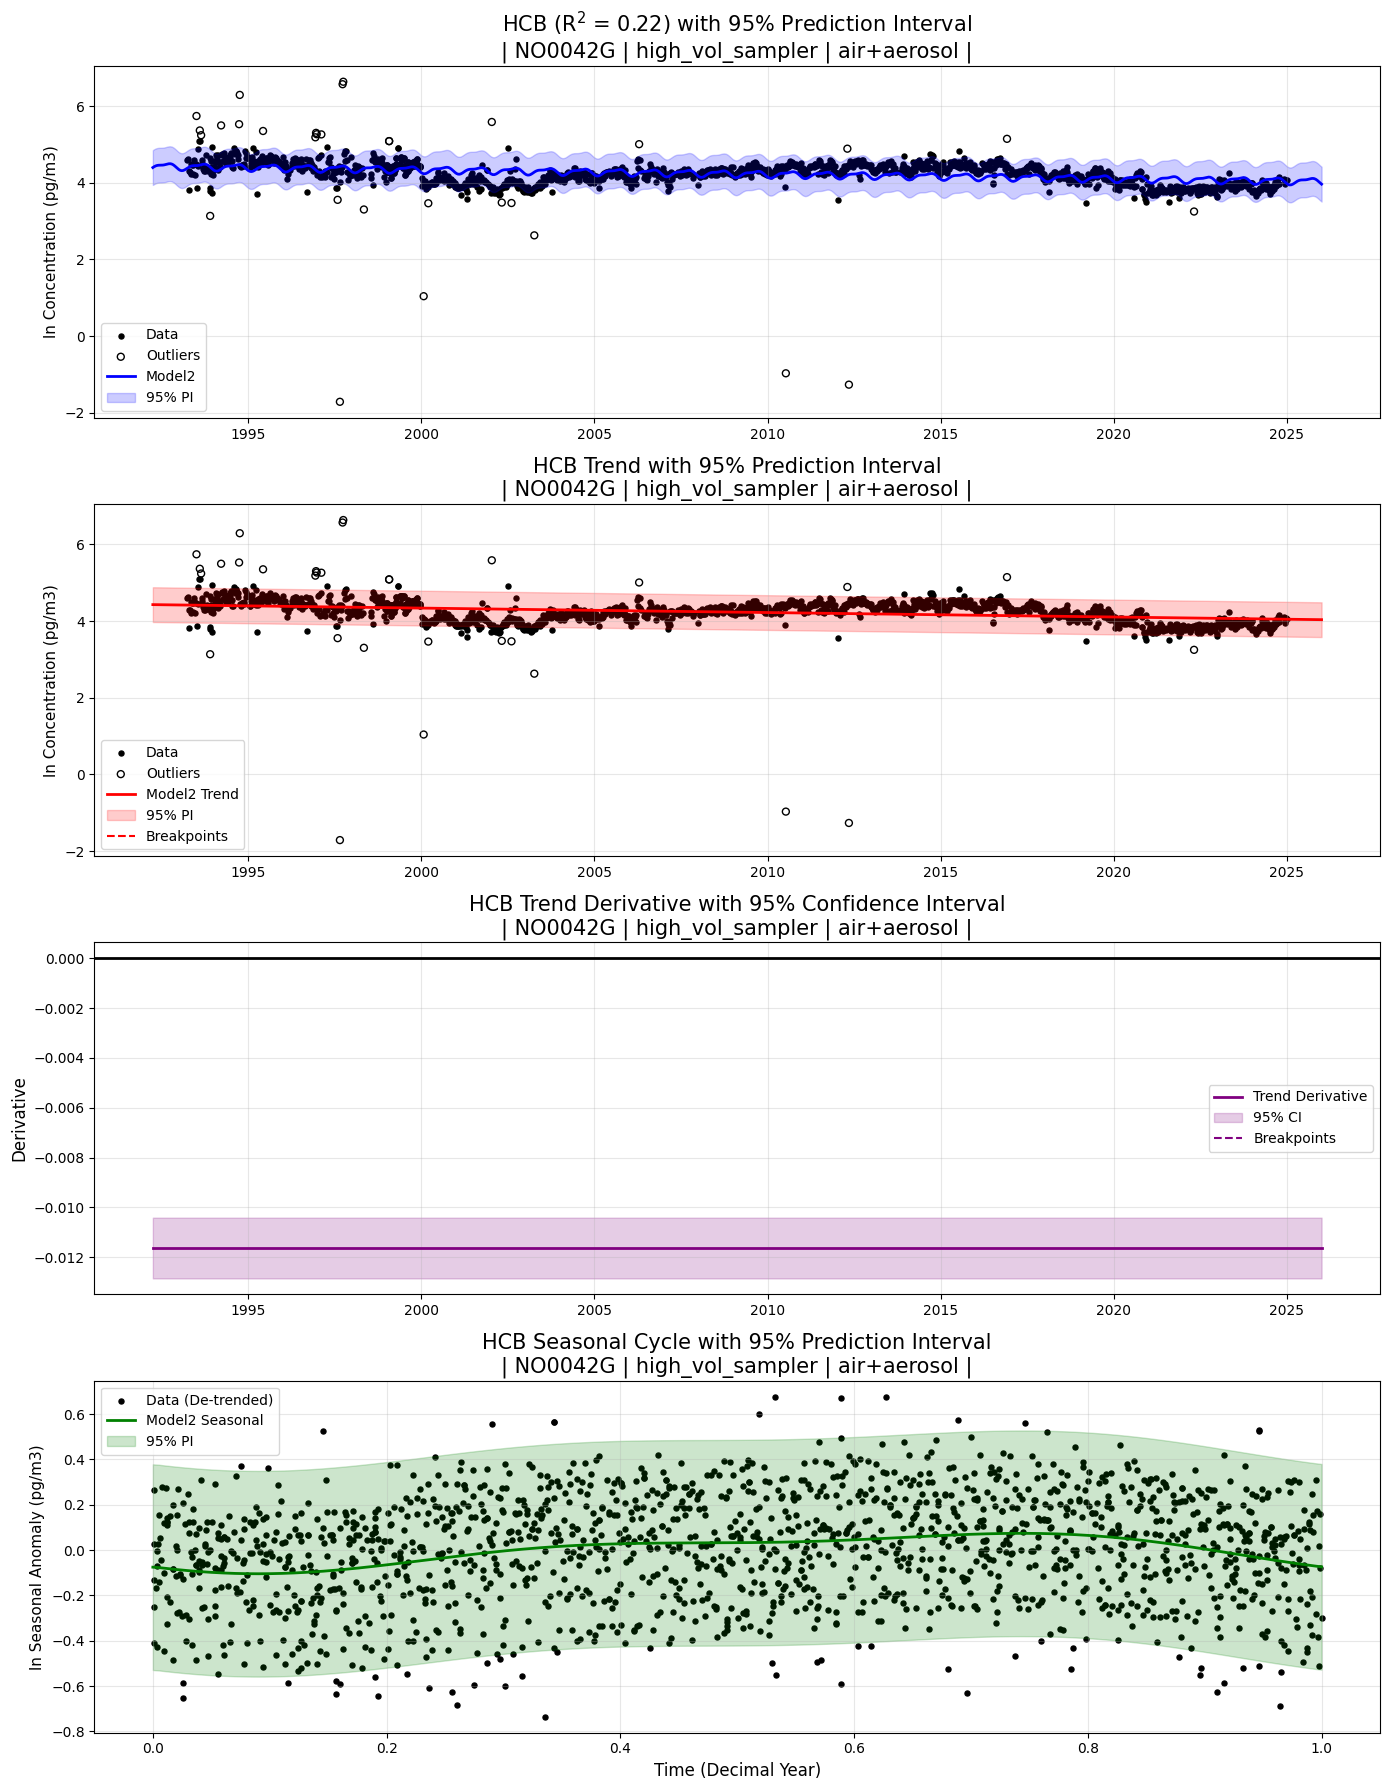

Multi-panel plot saved to: c:\XiaoyuGithub\SPLINTER\SPLINTER\outputdirs\NO0042G_HCB_high_vol_sampler_air+aerosol_output_SPLINTER_V012_20260602_132435\SPLINTER_Final_Summary_Plot.png

---- SPLINTER Half-life Summary Table ----

 Period (years)  Duration (years)  Slope (/year)  Slope p-value  Half-life (years)  Half-life 95% CI lower  Half-life 95% CI upper Description
1992.25–2025.00         32.746031      -0.011636   6.792312e-71           59.56888               53.915913               66.546093  decreasing


In [15]:
#13 --- Output Final Visualizations For Model 2 and a Table of Half-lives with Confidence Intervals ---
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from matplotlib.lines import Line2D

# --- Model2: Prediction Intervals, Derivatives, Clean Plotting DataFrame, and Multi-panel Plots ---
# 1. Get time range for clean plotting dataframe
start_time      = data_clean['time_y'].min()
end_time        = data_clean['time_y'].max()
plot_start_time = start_time - 1.0        # 1 year before first observation
plot_end_time   = end_time   + 1.0        # 1 year after last observation
n_plot_points   = max(300, int((plot_end_time - plot_start_time) * 24))  # ~2 points/month
plot_time_y     = np.linspace(plot_start_time, plot_end_time, n_plot_points)
# 2. Build design matrices for Model2 components at plot_time_y
n_harm2 = best_model2['n_harmonics']
knot_positions2 = best_model2['knot_positions']
if n_harm2 > 0:
    X_seasonal_plot, _ = fourier_basis_1year(plot_time_y, n_harm2)
else:
    X_seasonal_plot = np.array([]).reshape(len(plot_time_y), 0)
X_trend_plot = create_spline_basis(plot_time_y, knot_positions2)
X_plot = np.column_stack([X_seasonal_plot, X_trend_plot])
# 3. Get Model2 coefficients and covariance
coeffs2 = best_model2['coeffs']
cov_matrix2 = best_model2['cov_matrix']
t_critical2 = best_model2['t_critical']
residuals2 = best_model2['residuals']
n2 = len(residuals2)
p2 = best_model2['n_params']
sigma2_2 = np.sum(residuals2**2) / (n2 - p2)
# Calculate R-squared for Model2
ss_res = np.sum(residuals2**2)
ss_tot = np.sum((data_clean['ln_c'] - np.mean(data_clean['ln_c']))**2)
rsq_model2 = 1 - ss_res / ss_tot
# 4. Model2 predictions and prediction intervals
model2_pred = X_plot @ coeffs2
se_model2 = np.sqrt(np.sum(X_plot @ cov_matrix2 * X_plot, axis=1))
pred_model2 = np.sqrt(se_model2**2 + sigma2_2)
model2_pi_lower = model2_pred - t_critical2 * pred_model2
model2_pi_upper = model2_pred + t_critical2 * pred_model2
# 5. Trend component and prediction intervals
trend_start2, trend_end2 = best_model2['component_indices']['trend']
X_trend_only_plot = X_plot[:, trend_start2:trend_end2]
cov_trend2 = cov_matrix2[trend_start2:trend_end2, trend_start2:trend_end2]
trend_pred = X_trend_only_plot @ coeffs2[trend_start2:trend_end2]
se_trend = np.sqrt(np.sum(X_trend_only_plot @ cov_trend2 * X_trend_only_plot, axis=1))
pred_trend = np.sqrt(se_trend**2 + sigma2_2)
trend_pi_lower = trend_pred - t_critical2 * pred_trend
trend_pi_upper = trend_pred + t_critical2 * pred_trend
# 6. Seasonal component and prediction intervals
if best_model2['component_indices']['seasonal'] is not None:
    seas_start2, seas_end2 = best_model2['component_indices']['seasonal']
    X_seasonal_only_plot = X_plot[:, seas_start2:seas_end2]
    cov_seasonal2 = cov_matrix2[seas_start2:seas_end2, seas_start2:seas_end2]
    seasonal_pred = X_seasonal_only_plot @ coeffs2[seas_start2:seas_end2]
    se_seasonal = np.sqrt(np.sum(X_seasonal_only_plot @ cov_seasonal2 * X_seasonal_only_plot, axis=1))
    pred_seasonal = np.sqrt(se_seasonal**2 + sigma2_2)
    seasonal_pi_lower = seasonal_pred - t_critical2 * pred_seasonal
    seasonal_pi_upper = seasonal_pred + t_critical2 * pred_seasonal
else:
    seasonal_pred = np.zeros_like(plot_time_y)
    seasonal_pi_lower = np.zeros_like(plot_time_y)
    seasonal_pi_upper = np.zeros_like(plot_time_y)
# 7. Derivatives and confidence intervals (trend)
def derivative_and_ci(X, coeffs, cov, time_arr, t_critical):
    dt = np.gradient(time_arr)
    pred = X @ coeffs
    deriv = np.gradient(pred, time_arr)
    deriv_se = np.zeros_like(time_arr)
    for i in range(len(time_arr)):
        if i == 0:
            dXdt = (X[1] - X[0]) / (time_arr[1] - time_arr[0])
        elif i == len(time_arr) - 1:
            dXdt = (X[-1] - X[-2]) / (time_arr[-1] - time_arr[-2])
        else:
            dXdt = (X[i+1] - X[i-1]) / (time_arr[i+1] - time_arr[i-1])
        deriv_se[i] = np.sqrt(dXdt @ cov @ dXdt.T)
    deriv_ci_lower = deriv - t_critical * deriv_se
    deriv_ci_upper = deriv + t_critical * deriv_se
    return deriv, deriv_ci_lower, deriv_ci_upper
trend_deriv, trend_deriv_ci_lower, trend_deriv_ci_upper = derivative_and_ci(
    X_trend_only_plot, coeffs2[trend_start2:trend_end2], cov_trend2, plot_time_y, t_critical2)
# 8. Build clean plotting dataframe
plot_df = pd.DataFrame({
    'time_y': plot_time_y,
    'Model2': model2_pred,
    'Model2_pi_lower': model2_pi_lower,
    'Model2_pi_upper': model2_pi_upper,
    'Model2_trend': trend_pred,
    'Model2_trend_pi_lower': trend_pi_lower,
    'Model2_trend_pi_upper': trend_pi_upper,
    'Model2_seasonal': seasonal_pred,
    'Model2_seasonal_pi_lower': seasonal_pi_lower,
    'Model2_seasonal_pi_upper': seasonal_pi_upper,
    'Model2_trend_deriv': trend_deriv,
    'Model2_trend_deriv_ci_lower': trend_deriv_ci_lower,
    'Model2_trend_deriv_ci_upper': trend_deriv_ci_upper
})
# 9. Multi-panel column plots
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=False)
# Emphasis font sizes (25% smaller)
emph_title = 15
emph_label = 12
emph_legend = 10
emph_tick = 10
# Marker sizes
base_data_marker = 18
base_outlier_marker = 50
small_data_marker = int(base_data_marker * 0.75)
small_outlier_marker = int(base_outlier_marker * 0.5)
# Pre-compute MDL flag helpers — used in Panels 1, 2 and 4
_has_780 = 'flag_780' in data_clean.columns and data_clean['flag_780'].any()
_has_781 = 'flag_781' in data_clean.columns and data_clean['flag_781'].any()
label_781 = '781. 0.5xMDL' if handle_flag_781 == 'Replace' else '781. Kept as MDL'
# Mask for points that are NOT flagged 780 or 781 (these get the default black dot)
unflagged_mask = pd.Series(True, index=data_clean.index)
if 'flag_780' in data_clean.columns:
    unflagged_mask = unflagged_mask & ~data_clean['flag_780']
if 'flag_781' in data_clean.columns:
    unflagged_mask = unflagged_mask & ~data_clean['flag_781']
# ── Panel 1: Data + Model2 with PI ──────────────────────────────────────────
outlier_mask = data['Model1_z_outlier']
axes[0].scatter(data_clean.loc[unflagged_mask, 'time_y'], data_clean.loc[unflagged_mask, 'ln_c'],
                c='black', s=small_data_marker, label='Data')
axes[0].scatter(data.loc[outlier_mask, 'time_y'], data.loc[outlier_mask, 'ln_c'],
                facecolors='none', edgecolors='black', s=small_outlier_marker, label='Outliers')
if _has_780:
    axes[0].scatter(data_clean.loc[data_clean['flag_780'], 'time_y'],
                    data_clean.loc[data_clean['flag_780'], 'ln_c'],
                    marker='<', facecolors='none', edgecolors='gray', s=small_data_marker * 2, zorder=5, label='780. <MDL but reported')
if _has_781:
    axes[0].scatter(data_clean.loc[data_clean['flag_781'], 'time_y'],
                    data_clean.loc[data_clean['flag_781'], 'ln_c'],
                    marker='_', c='gray', s=small_data_marker * 4, linewidths=1.5, zorder=5, label=label_781)
axes[0].plot(plot_df['time_y'], plot_df['Model2'], color='blue', linewidth=2, label='Model2')
axes[0].fill_between(plot_df['time_y'], plot_df['Model2_pi_lower'], plot_df['Model2_pi_upper'],
                     color='blue', alpha=0.2, label='95% PI')
axes[0].set_ylabel(f'ln Concentration ({ts.attrs.get("units", "")})', fontsize=_emph_label)
axes[0].set_title(f'{input_subst} (R$^2$ = {rsq_model2:.2f}) with 95% Prediction Interval\n| {station_code} | {instrument_type} | {matrix} |',
                  fontsize=emph_title)
axes[0].legend(fontsize=emph_legend)
# ── Panel 2: Model2 Trend with PI + data ────────────────────────────────────
axes[1].scatter(data_clean.loc[unflagged_mask, 'time_y'], data_clean.loc[unflagged_mask, 'ln_c'],
                c='black', s=small_data_marker, label='Data')
axes[1].scatter(data.loc[outlier_mask, 'time_y'], data.loc[outlier_mask, 'ln_c'],
                facecolors='none', edgecolors='black', s=small_outlier_marker, label='Outliers')
if _has_780:
    axes[1].scatter(data_clean.loc[data_clean['flag_780'], 'time_y'],
                    data_clean.loc[data_clean['flag_780'], 'ln_c'],
                    marker='<', facecolors='none', edgecolors='gray', s=small_data_marker * 2, zorder=5, label='780. <MDL but reported')
if _has_781:
    axes[1].scatter(data_clean.loc[data_clean['flag_781'], 'time_y'],
                    data_clean.loc[data_clean['flag_781'], 'ln_c'],
                    marker='_', c='gray', s=small_data_marker * 4, linewidths=1.5, zorder=5, label=label_781)
axes[1].plot(plot_df['time_y'], plot_df['Model2_trend'], color='red', linewidth=2, label='Model2 Trend')
axes[1].fill_between(plot_df['time_y'], plot_df['Model2_trend_pi_lower'], plot_df['Model2_trend_pi_upper'],
                     color='red', alpha=0.2, label='95% PI')
for knot in knot_positions2:
    axes[1].axvline(x=knot, color='red', linestyle='--', linewidth=1, label=None)
custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5)]
axes[1].legend(handles=axes[1].get_legend_handles_labels()[0] + custom_lines,
               labels=axes[1].get_legend_handles_labels()[1] + ['Breakpoints'], fontsize=emph_legend)
axes[1].set_ylabel(f'ln Concentration ({ts.attrs.get("units", "")})', fontsize=_emph_label)
axes[1].set_title(f"{input_subst} Trend with 95% Prediction Interval\n| {station_code} | {instrument_type} | {matrix} |", fontsize=emph_title)
# ── Panel 3: Trend derivative with CI ───────────────────────────────────────
axes[2].plot(plot_df['time_y'], plot_df['Model2_trend_deriv'], color='purple', linewidth=2, label='Trend Derivative')
axes[2].fill_between(plot_df['time_y'], plot_df['Model2_trend_deriv_ci_lower'], plot_df['Model2_trend_deriv_ci_upper'],
                     color='purple', alpha=0.2, label='95% CI')
for knot in knot_positions2:
    axes[2].axvline(x=knot, color='purple', linestyle='--', linewidth=1, label=None)
    axes[2].text(knot, axes[2].get_ylim()[1], f'{knot:.2f}', color='purple', fontsize=emph_tick,
                 ha='right', va='top', rotation=90)
custom_lines_deriv = [Line2D([0], [0], color='purple', linestyle='--', linewidth=1.5)]
axes[2].legend(handles=axes[2].get_legend_handles_labels()[0] + custom_lines_deriv,
               labels=axes[2].get_legend_handles_labels()[1] + ['Breakpoints'], fontsize=emph_legend)
axes[2].set_ylabel('Derivative', fontsize=emph_label)
axes[2].set_title(f"{input_subst} Trend Derivative with 95% Confidence Interval\n| {station_code} | {instrument_type} | {matrix} |",
                  fontsize=emph_title)
axes[2].axhline(y=0, color='black', linewidth=2, linestyle='-')
ymin, ymax = axes[2].get_ylim()
axes[2].set_ylim(min(ymin, 0), max(ymax, 0) if ymax < 0 else ymax)
# ── Panel 4: Seasonal cycle (de-trended data) ────────────────────────────────
seasonal_phase = data_clean['time_y'] % 1.0
trend_pred_interp = np.interp(data_clean['time_y'], plot_df['time_y'], plot_df['Model2_trend'])
detrended_data = data_clean['ln_c'] - trend_pred_interp
seasonal_plot_phase = np.linspace(0, 1, 200)
phase_for_interp = plot_df['time_y'] % 1.0
sort_idx = np.argsort(phase_for_interp)
phase_sorted = phase_for_interp[sort_idx]
seasonal_sorted = plot_df['Model2_seasonal'].values[sort_idx]
seasonal_pi_lower_sorted = plot_df['Model2_seasonal_pi_lower'].values[sort_idx]
seasonal_pi_upper_sorted = plot_df['Model2_seasonal_pi_upper'].values[sort_idx]
seasonal_pred_interp = np.interp(seasonal_plot_phase, phase_sorted, seasonal_sorted)
seasonal_pi_lower_interp = np.interp(seasonal_plot_phase, phase_sorted, seasonal_pi_lower_sorted)
seasonal_pi_upper_interp = np.interp(seasonal_plot_phase, phase_sorted, seasonal_pi_upper_sorted)
axes[3].scatter(seasonal_phase[unflagged_mask], detrended_data[unflagged_mask],
                c='black', s=small_data_marker, label='Data (De-trended)')
if _has_780:
    axes[3].scatter(seasonal_phase[data_clean['flag_780']],
                    detrended_data[data_clean['flag_780']],
                    marker='<', facecolors='none', edgecolors='gray', s=small_data_marker * 2, zorder=5, label='780. <MDL but reported')
if _has_781:
    axes[3].scatter(seasonal_phase[data_clean['flag_781']],
                    detrended_data[data_clean['flag_781']],
                    marker='_', c='gray', s=small_data_marker * 4, linewidths=1.5, zorder=5, label=label_781)
axes[3].plot(seasonal_plot_phase, seasonal_pred_interp, color='green', linewidth=2, label='Model2 Seasonal')
axes[3].fill_between(seasonal_plot_phase, seasonal_pi_lower_interp, seasonal_pi_upper_interp,
                     color='green', alpha=0.2, label='95% PI')
axes[3].set_ylabel(f'ln Seasonal Anomaly ({ts.attrs.get("units", "")})', fontsize=_emph_label)
axes[3].set_title(f"{input_subst} Seasonal Cycle with 95% Prediction Interval\n| {station_code} | {instrument_type} | {matrix} |",
                  fontsize=emph_title)
axes[3].legend(fontsize=emph_legend)
# ─────────────────────────────────────────────────────────────────────────────
for ax in axes:
    ax.tick_params(axis='both', labelsize=emph_tick)
    ax.grid(True, alpha=0.3)
plt.xlabel('Time (Decimal Year)', fontsize=emph_label)
plt.tight_layout()
plt.show()
save_plot(fig, f'SPLINTER_Final_Summary_Plot_{_label_fn}')
if save_outputs:
    _plot_df_out = plot_df.drop(columns=['Model2_trend_deriv', 'Model2_trend_deriv_ci_lower', 'Model2_trend_deriv_ci_upper'], errors='ignore').rename(columns=lambda c: c.replace('Model2', 'SPLINTER'))
    _header_lines = []
    for _line in (_file_list_text + _settings_tbl1 + _settings_tbl2).splitlines():
        _header_lines.append(('# ' + _line) if _line.strip() else '#')
    _header_lines += [
        '#',
        '# Notes on column names:',
        f'# Units: {ts.attrs.get("units", "unknown")}',
        '# All values are natural log (ln) transformed.',
        '#   pi = prediction interval (95%, two-tailed)',
        '#',
    ]
    _num = get_next_output_number()
    _csv_path = os.path.join(output_dir, f'{_num:02d}_SPLINTER_Final_Model_PlottingData_{_label_fn}.csv')
    with open(_csv_path, 'w', encoding='utf-8-sig') as _f:
        for _hl in _header_lines:
            _f.write(_hl + chr(10))
        _plot_df_out.to_csv(_f, index=False, lineterminator='\n')

# 10. Half-life table with confidence intervals
# --- Calculate Half-life Table for Model2 Trend Spline Segments ---
knots = np.concatenate(([plot_df['time_y'].min()], knot_positions2, [data['time_y'].max()]))
n_segments = len(knots) - 1

periods = []
durations = []
slopes = []
half_lives = []
hl_ci_lower = []
hl_ci_upper = []
descriptions = []

for i in range(n_segments):
    mask = (plot_df['time_y'] >= knots[i]) & (plot_df['time_y'] < knots[i+1])
    segment_slope = np.mean(plot_df.loc[mask, 'Model2_trend_deriv'])
    segment_slope_ci_lower = np.mean(plot_df.loc[mask, 'Model2_trend_deriv_ci_lower'])
    segment_slope_ci_upper = np.mean(plot_df.loc[mask, 'Model2_trend_deriv_ci_upper'])
    duration = knots[i+1] - knots[i]
    hl = -np.log(2) / segment_slope if segment_slope != 0 else np.nan
    hl_lower = -np.log(2) / segment_slope_ci_lower if segment_slope_ci_lower != 0 else np.nan
    hl_upper = -np.log(2) / segment_slope_ci_upper if segment_slope_ci_upper != 0 else np.nan
    if hl_lower > 0 and hl_upper > 0:
        desc = "decreasing"
    elif hl_lower < 0 and hl_upper > 0:
        desc = "steady"
    elif hl_upper < 0 and hl_lower < 0:
        desc = "increasing"
    else:
        desc = "uncertain"
    periods.append(f"{knots[i]:.2f}–{knots[i+1]:.2f}")
    durations.append(duration)
    slopes.append(segment_slope)
    half_lives.append(hl)
    hl_ci_lower.append(hl_lower)
    hl_ci_upper.append(hl_upper)
    descriptions.append(desc)

half_life_df = pd.DataFrame({
    "Period (years)": periods,
    "Duration (years)": durations,
    "Slope (/year)": slopes,
    "Half-life (years)": half_lives,
    "Half-life 95% CI lower": hl_ci_lower,
    "Half-life 95% CI upper": hl_ci_upper,
    "Description": descriptions
})

# 11. Add p-value for slope to Splinter_HalfLife_Table
# For each segment, recover the pointwise derivative SE from the CI bounds:
#   SE = (CI_upper - CI_lower) / (2 * t_critical2)
# then use the mean SE over the segment to compute a t-statistic and two-tailed p-value.
df_resid = n2 - p2
slope_pvalues = []
for i in range(n_segments):
    mask = (plot_df['time_y'] >= knots[i]) & (plot_df['time_y'] < knots[i+1])
    deriv_se_segment = (
        plot_df.loc[mask, 'Model2_trend_deriv_ci_upper'] -
        plot_df.loc[mask, 'Model2_trend_deriv_ci_lower']
    ) / (2 * t_critical2)
    se_slope = deriv_se_segment.mean()
    seg_slope = slopes[i]
    if se_slope > 0:
        t_stat = seg_slope / se_slope
        p_val = 2 * sp_stats.t.sf(abs(t_stat), df=df_resid)
    else:
        p_val = np.nan
    slope_pvalues.append(p_val)

# Insert "Slope p-value" column between "Slope (/year)" and "Half-life (years)"
slope_col_idx = half_life_df.columns.get_loc("Slope (/year)")
half_life_df.insert(slope_col_idx + 1, "Slope p-value", slope_pvalues)

#save_df(half_life_df, f'SPLINTER_HalfLife_Table_{input_subst}_{station_label_fn}')
half_life_text = half_life_df.to_string(index=False)
save_text(half_life_text, f'SPLINTER_HalfLife_Summary_{_label_fn}')
print(f"Multi-panel plot saved to: {os.path.join(output_dir, 'SPLINTER_Final_Summary_Plot.png')}")
print("")
print("---- SPLINTER Half-life Summary Table ----")
print("")
print(half_life_text)


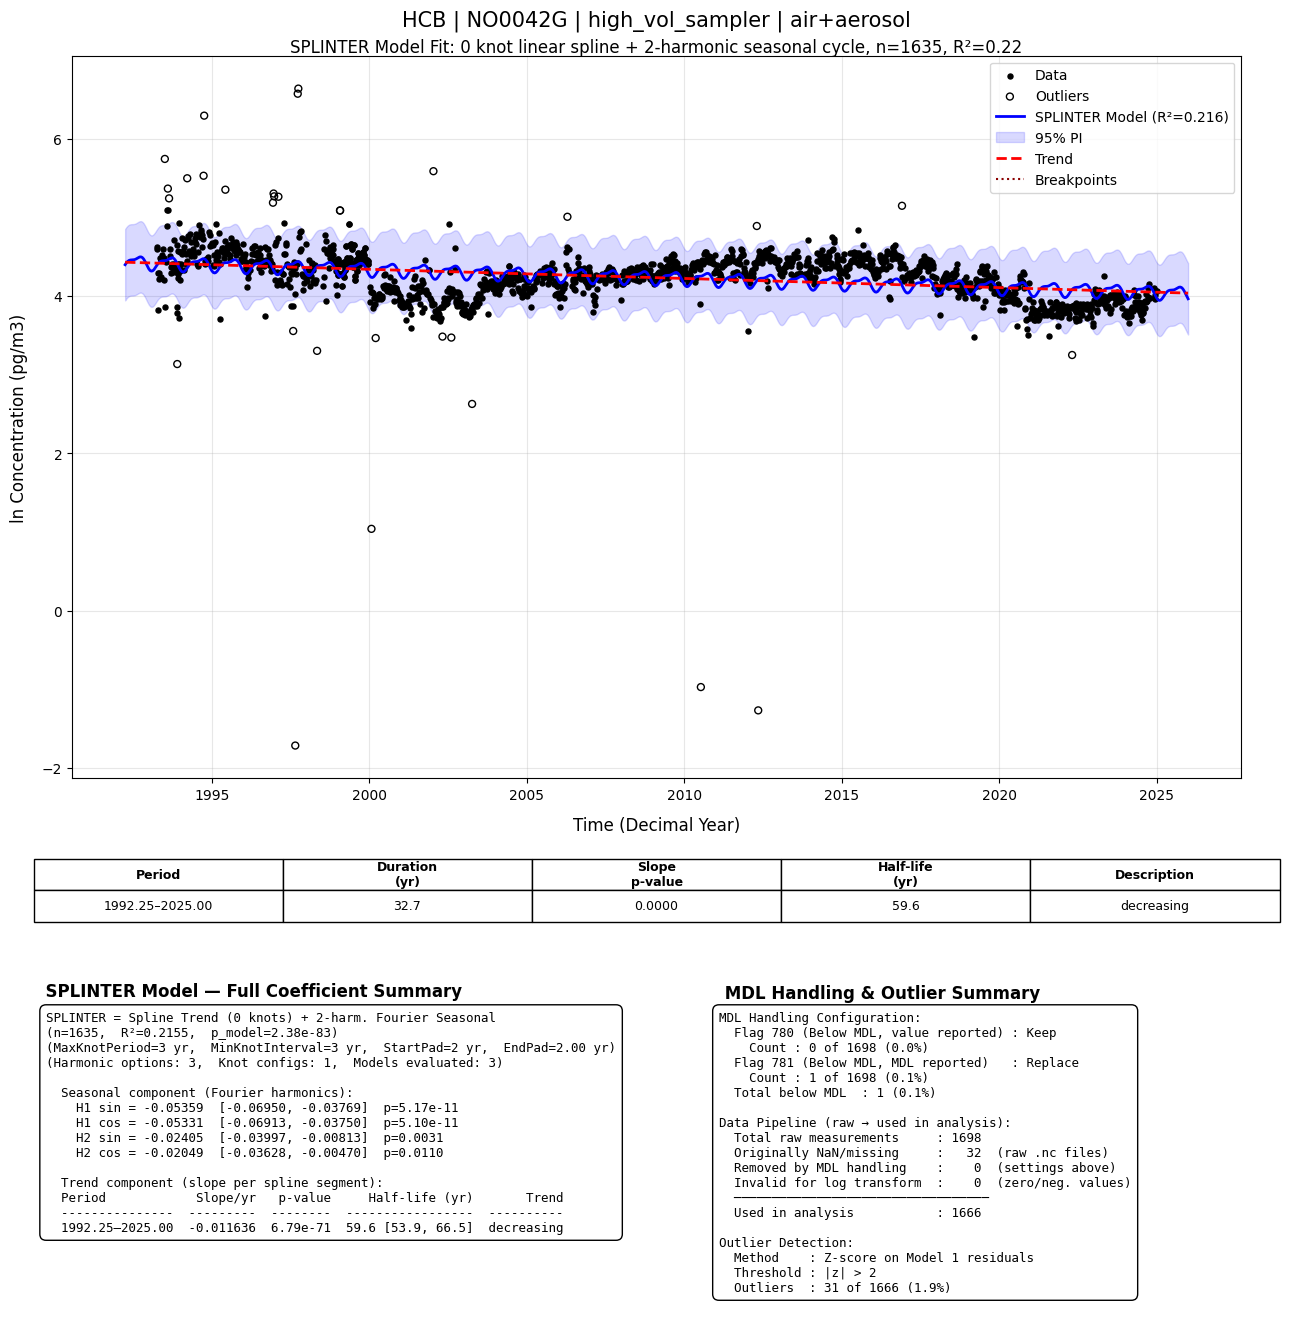

In [16]:
# Cell 18 --- Concise SPLINTER Summary Figure + Half-life Table ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy import stats as sp_stats

# ── Pre-compute model summary annotation lines (needed before figure sizing) ──
_se_ann    = np.sqrt(np.diag(cov_matrix2))
_tstat_ann = np.where(_se_ann > 0, coeffs2 / _se_ann, np.nan)
_pval_ann  = np.where(np.isfinite(_tstat_ann),
                      2.0 * sp_stats.t.sf(np.abs(_tstat_ann), df=df_resid), np.nan)
_cilo_ann  = coeffs2 - t_critical2 * _se_ann
_cihi_ann  = coeffs2 + t_critical2 * _se_ann

def _pfmt_s(p):
    try:
        if pd.isna(p) or not np.isfinite(p):
            return 'N/A'
    except (TypeError, ValueError):
        return 'N/A'
    return f'{float(p):.2e}' if float(p) < 0.001 else f'{float(p):.4f}'

# Overall model F-test p-value
_ss_res_ann = np.sum(residuals2**2)
_ss_tot_ann = np.sum((data_clean['ln_c'] - np.mean(data_clean['ln_c']))**2)
_F_ann  = ((_ss_tot_ann - _ss_res_ann) / (p2 - 1)) / (_ss_res_ann / df_resid)
_pF_ann = sp_stats.f.sf(_F_ann, dfn=p2 - 1, dfd=df_resid)

_n_knots_ann = len(knot_positions2)
_ann = [
    f"SPLINTER = Spline Trend ({_n_knots_ann} knot{'s' if _n_knots_ann != 1 else ''}) + "
    f"{n_harm2}-harm. Fourier Seasonal",
    f"(n={n2},  R\u00b2={rsq_model2:.4f},  p_model={_pfmt_s(_pF_ann)})",
    f"(MaxKnotPeriod={MaxKnotPeriod} yr,  MinKnotInterval={MinKnotInterval} yr,  StartPad={StartPad} yr,  EndPad={EndPad:.2f} yr)",
    f"(Harmonic options: {len(harmonics_range)},  Knot configs: {len(valid_knot_configs)},  Models evaluated: {total_models})",
    "",
    "  Seasonal component (Fourier harmonics):",
]
if best_model2['component_indices']['seasonal'] is not None and n_harm2 > 0:
    for _k in range(n_harm2):
        _si = seas_start2 + 2 * _k
        _ci = seas_start2 + 2 * _k + 1
        _ann.append(
            f"    H{_k+1} sin = {coeffs2[_si]:+.5f}  [{_cilo_ann[_si]:+.5f}, {_cihi_ann[_si]:+.5f}]"
            f"  p={_pfmt_s(_pval_ann[_si])}"
        )
        _ann.append(
            f"    H{_k+1} cos = {coeffs2[_ci]:+.5f}  [{_cilo_ann[_ci]:+.5f}, {_cihi_ann[_ci]:+.5f}]"
            f"  p={_pfmt_s(_pval_ann[_ci])}"
        )
else:
    _ann.append("    (no seasonal component)")

_ann.append("")
_ann.append("  Trend component (slope per spline segment):")

# ── Build trend table rows first so column widths can be computed dynamically ─
_trend_hdr  = ('Period', 'Slope/yr', 'p-value', 'Half-life (yr)', 'Trend')
_trend_rows = []
for _, _row in half_life_df.iterrows():
    _slp  = _row['Slope (/year)']
    _pv   = _row['Slope p-value']
    _hl   = _row['Half-life (years)']
    _hllo = _row['Half-life 95% CI lower']
    _hlhi = _row['Half-life 95% CI upper']
    _prd  = str(_row['Period (years)'])
    _dsc  = str(_row['Description'])
    _slp_s = f"{_slp:+.6f}"
    _pv_s  = _pfmt_s(float(_pv)) if pd.notna(_pv) else 'N/A'
    if pd.notna(_hl) and np.isfinite(_hl):
        _hl_val = f"{_hl:.1f}"
        if (pd.notna(_hllo) and pd.notna(_hlhi)
                and np.isfinite(_hllo) and np.isfinite(_hlhi)):
            _hl_s = f"{_hl_val} [{min(_hllo, _hlhi):.1f}, {max(_hllo, _hlhi):.1f}]"
        else:
            _hl_s = _hl_val
    else:
        _hl_s = 'N/A'
    _trend_rows.append((_prd, _slp_s, _pv_s, _hl_s, _dsc))

# Compute per-column widths: max of header width and all data widths
_cw = [
    max(len(_trend_hdr[i]), max((len(r[i]) for r in _trend_rows), default=0))
    for i in range(len(_trend_hdr))
]

# Col 0 (Period) left-aligned; cols 1-4 right-aligned
_ann.append(
    f"  {_trend_hdr[0]:<{_cw[0]}}  {_trend_hdr[1]:>{_cw[1]}}  "
    f"{_trend_hdr[2]:>{_cw[2]}}  {_trend_hdr[3]:>{_cw[3]}}  {_trend_hdr[4]:>{_cw[4]}}"
)
_ann.append(
    f"  {'-'*_cw[0]}  {'-'*_cw[1]}  {'-'*_cw[2]}  {'-'*_cw[3]}  {'-'*_cw[4]}"
)
for _r in _trend_rows:
    _ann.append(
        f"  {_r[0]:<{_cw[0]}}  {_r[1]:>{_cw[1]}}  "
        f"{_r[2]:>{_cw[2]}}  {_r[3]:>{_cw[3]}}  {_r[4]:>{_cw[4]}}"
    )

_ann_text = "\n".join(_ann)

# ── Build MDL Handling & Outlier summary text (for bottom-right panel) ────────
_n_outliers   = int(outlier_mask.sum())
_n_total_data = len(data)
_pct_outliers = _n_outliers / _n_total_data * 100 if _n_total_data > 0 else 0.0

_n_orig_nan    = int(np.isnan(ts_values.astype(float)).sum())
_n_mdl_removed = int(np.isnan(ts_values_float).sum()) - _n_orig_nan
_n_log_invalid = total_measurements - _n_orig_nan - _n_mdl_removed - _n_total_data

_mdl_outlier_lines = "\n".join([
    "MDL Handling Configuration:",
    f"  Flag 780 (Below MDL, value reported) : {handle_flag_780}",
    f"    Count : {count_780} of {total_measurements} ({pct_780:.1f}%)",
    f"  Flag 781 (Below MDL, MDL reported)   : {handle_flag_781}",
    f"    Count : {count_781} of {total_measurements} ({pct_781:.1f}%)",
    f"  Total below MDL  : {count_mdl_total} ({pct_mdl:.1f}%)",
    "",
    "Data Pipeline (raw \u2192 used in analysis):",
    f"  Total raw measurements     : {total_measurements}",
    f"  Originally NaN/missing     : {_n_orig_nan:4d}  (raw .nc files)",
    f"  Removed by MDL handling    : {_n_mdl_removed:4d}  (settings above)",
    f"  Invalid for log transform  : {_n_log_invalid:4d}  (zero/neg. values)",
    f"  {chr(9472)*34}",
    f"  Used in analysis           : {_n_total_data}",
    "",
    "Outlier Detection:",
    f"  Method    : Z-score on Model 1 residuals",
    f"  Threshold : |z| > {z_thresh}",
    f"  Outliers  : {_n_outliers} of {_n_total_data} ({_pct_outliers:.1f}%)",
])

# ── Figure layout: plot | concise table | detail panel ───────────────────────
_n_tbl_rows  = len(half_life_df)
_n_ann_lines = len(_ann)
_plot_h  = 9.0
_tbl_h   = 0.6 + 0.35 * _n_tbl_rows
_det_h   = 0.5 + _n_ann_lines * 0.22

_golden  = (1 + 5**0.5) / 2             # ≈ 1.618
fig_conc = plt.figure(figsize=(14, _plot_h + _tbl_h + _det_h))
gs = gridspec.GridSpec(3, 1, figure=fig_conc,
                       height_ratios=[_plot_h, _tbl_h, _det_h],
                       hspace=0.2)
ax_plot = fig_conc.add_subplot(gs[0])
ax_tbl  = fig_conc.add_subplot(gs[1])
ax_det  = fig_conc.add_subplot(gs[2])

# ── Plot: Data + Outliers + MDL flags + SPLINTER Model + Trend + Breakpoints ──
ax_plot.scatter(
    data_clean.loc[unflagged_mask, 'time_y'],
    data_clean.loc[unflagged_mask, 'ln_c'],
    c='black', s=small_data_marker, label='Data', zorder=3)

ax_plot.scatter(
    data.loc[outlier_mask, 'time_y'],
    data.loc[outlier_mask, 'ln_c'],
    facecolors='none', edgecolors='black', s=small_outlier_marker,
    label='Outliers', zorder=3)

if _has_780:
    ax_plot.scatter(
        data_clean.loc[data_clean['flag_780'], 'time_y'],
        data_clean.loc[data_clean['flag_780'], 'ln_c'],
        marker='<', facecolors='none', edgecolors='gray',
        s=small_data_marker * 2, zorder=5, label='780. <MDL but reported')
if _has_781:
    ax_plot.scatter(
        data_clean.loc[data_clean['flag_781'], 'time_y'],
        data_clean.loc[data_clean['flag_781'], 'ln_c'],
        marker='_', c='gray', s=small_data_marker * 4,
        linewidths=1.5, zorder=5, label=label_781)

ax_plot.plot(plot_df['time_y'], plot_df['Model2'],
             color='blue', linewidth=2,
             label=f'SPLINTER Model (R\u00b2={rsq_model2:.3f})', zorder=4)
ax_plot.fill_between(plot_df['time_y'],
                     plot_df['Model2_pi_lower'], plot_df['Model2_pi_upper'],
                     color='blue', alpha=0.15, label='95% PI', zorder=2)

ax_plot.plot(plot_df['time_y'], plot_df['Model2_trend'],
             color='red', linewidth=2, linestyle='--',
             label='Trend', zorder=4)

for _knot in knot_positions2:
    ax_plot.axvline(x=_knot, color='darkred', linestyle=':', linewidth=1.2, zorder=2)
    ax_plot.text(_knot, ax_plot.get_ylim()[1], f'{_knot:.2f}',
                 color='darkred', fontsize=emph_tick,
                 ha='right', va='top', rotation=90)
_bkpt_handle = Line2D([0], [0], color='darkred', linestyle=':', linewidth=1.5)
_handles, _labels = ax_plot.get_legend_handles_labels()
ax_plot.legend(_handles + [_bkpt_handle], _labels + ['Breakpoints'],
               fontsize=emph_legend, loc='best')

ax_plot.set_ylabel(f'ln Concentration ({ts.attrs.get("units", "")})', fontsize=emph_label, labelpad=10)
ax_plot.set_xlabel('Time (Decimal Year)', fontsize=emph_label, labelpad=10)
ax_plot.tick_params(axis='both', labelsize=emph_tick)
ax_plot.grid(True, alpha=0.3)
ax_plot.set_box_aspect(1 / _golden)  # plot frame width:height = golden ratio

# Title: first line larger, second line at standard label size
ax_plot.set_title(
    f'{input_subst} | {station_code} | {instrument_type} | {matrix}',
    fontsize=emph_title, pad=22)
ax_plot.text(0.5, 1.0,
    f'SPLINTER Model Fit: {_n_knots_ann} knot linear spline + {n_harm2}-harmonic seasonal cycle, n={n2}, R\u00b2={rsq_model2:.2f}',
    transform=ax_plot.transAxes,
    fontsize=emph_label, ha='center', va='bottom')

# ── Concise Half-life Summary Table ──────────────────────────────────────────
_tbl_cols = ['Period (years)', 'Duration (years)', 'Slope p-value',
             'Half-life (years)', 'Description']
_tbl_df = half_life_df[_tbl_cols].copy()

_tbl_df['Duration (years)'] = _tbl_df['Duration (years)'].apply(
    lambda x: f'{x:.1f}')
_tbl_df['Slope p-value'] = _tbl_df['Slope p-value'].apply(
    lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')
_tbl_df['Half-life (years)'] = _tbl_df['Half-life (years)'].apply(
    lambda x: f'{x:.1f}' if (pd.notna(x) and np.isfinite(x)) else 'N/A')

_col_labels = ['Period', 'Duration\n(yr)', 'Slope\np-value',
               'Half-life\n(yr)', 'Description']
_cell_text  = _tbl_df.values.tolist()

ax_tbl.axis('off')
tbl_conc = ax_tbl.table(
    cellText=_cell_text, colLabels=_col_labels,
    loc='center', cellLoc='center')
tbl_conc.auto_set_font_size(False)
tbl_conc.set_fontsize(9)
tbl_conc.scale(1, 1.6)

for _j in range(len(_col_labels)):
    tbl_conc[(0, _j)].set_facecolor('white')
    tbl_conc[(0, _j)].set_text_props(fontweight='bold')

# ── Detailed model summary panel ──────────────────────────────────────────────
ax_det.axis('off')
ax_det.set_title('  SPLINTER Model \u2014 Full Coefficient Summary',
                 fontsize=emph_label, pad=4, loc='left', fontweight='bold')
ax_det.text(0.01, 0.97, _ann_text,
            transform=ax_det.transAxes,
            fontsize=9, va='top', ha='left', family='monospace',
            bbox=dict(facecolor='white', alpha=1.0, edgecolor='black',
                      boxstyle='round,pad=0.5'))

# ── MDL Handling & Outlier summary (bottom-right) ─────────────────────────────
ax_det.text(0.55, 1.0, ' MDL Handling & Outlier Summary',
            transform=ax_det.transAxes,
            fontsize=emph_label, fontweight='bold',
            va='bottom', ha='left', clip_on=False)
ax_det.text(0.55, 0.97, _mdl_outlier_lines,
            transform=ax_det.transAxes,
            fontsize=9, va='top', ha='left', family='monospace',
            bbox=dict(facecolor='white', alpha=1.0, edgecolor='black',
                      boxstyle='round,pad=0.5'))

fig_conc.subplots_adjust(left=0.08, right=0.97, top=0.93, bottom=0.02)
plt.show()
save_plot(fig_conc, f'SPLINTER_Concise_Summary_{_label_fn}')